# 04 -- Model selection: which interaction topology fits best?

We compare five chromosome interaction topologies:

| Label | xy partner(s) | xx term? |
|---|---|---|
| **poles** | both poles (2 partners) | no |
| **center** | pole midpoint (1 partner) | no |
| **poles\_and\_chroms** | both poles | yes (full range) |
| **center\_and\_chroms** | pole midpoint | yes (full range) |
| **poles\_and\_chroms\_enveloped** | both poles | yes (smooth steric envelope, r0=1.5 um, w=0.3 um — kernel ~0 by 2 um) |

Primary selection criterion: leave-one-cell-out deterministic drift-rollout
MSE (single noise-free ODE forward integration of the fitted drift,
scoring the conditional-mean trajectory to isolate systematic drift bias).
Secondary quantitative checks: one-step velocity MSE, endpoint mismatch,
final-frame distribution mismatch, and horizon-specific rollout errors.
Secondary qualitative checks: bootstrap CIs, kernel physics checks, and
representative forward simulations.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from chromlearn import find_repo_root

ROOT = find_repo_root(Path(__file__).resolve().parent if "__file__" in dir() else Path.cwd())

from chromlearn.io.catalog import load_condition
from chromlearn.io.trajectory import (
    TrimmedCell,
    get_partners,
    spindle_frame,
    trim_trajectory,
)
from chromlearn.model_fitting import FitConfig
from chromlearn.model_fitting.basis import BSplineBasis
from chromlearn.model_fitting.features import build_design_matrix
from chromlearn.model_fitting.fit import (
    BootstrapResult,
    CVResult,
    RolloutCVResult,
    bootstrap_kernels,
    cross_validate,
    fit_model,
    paired_cv_differences,
    rollout_cross_validate,
)
from chromlearn.model_fitting.model import FittedModel
from chromlearn.model_fitting.plotting import plot_cv_curve, plot_kernels
from chromlearn.model_fitting.simulate import simulate_cell, simulate_trajectories
from chromlearn.analysis.pca_projection import fit_pca_basis

plt.rcParams["figure.dpi"] = 110

## Configuration

In [2]:
CONDITION = "rpe18_ctr"          # Control-condition cells used for topology selection.
FRAC_NEB_AO_WINDOW = 0.4         # Baseline trajectory window as a fraction of NEB-to-AO.
N_BASIS = 10                     # Number of spline basis functions per interaction kernel.
LAMBDA_RIDGE = 1e-6              # Fixed numerical jitter; not a tuning knob.
LAMBDA_ROUGH = 1.0               # Integrated 2nd-derivative penalty (controls kernel smoothness).
BASIS_TYPE = "bspline"           # Functional basis used for the learned kernels.
BASIS_EVAL_MODE = "ito"          # SFI convention for evaluating the drift basis.
DT = 5.0                         # Frame interval in seconds.

cells_raw = load_condition(CONDITION)
cells = [trim_trajectory(c, method="neb_ao_frac", frac=FRAC_NEB_AO_WINDOW) for c in cells_raw]
print(f"Loaded {len(cells)} {CONDITION} cells (trimmed to neb_ao_frac={FRAC_NEB_AO_WINDOW:.3f} window)")
for c in cells:
    T, _, N = c.chromosomes.shape
    print(f"  {c.cell_id}: {T} frames, {N} chromosomes")

Loaded 12 rpe18_ctr cells (trimmed to neb_ao_frac=0.400 window)
  rpe18_ctr_006: 85 frames, 46 chromosomes
  rpe18_ctr_032: 93 frames, 46 chromosomes
  rpe18_ctr_034: 92 frames, 46 chromosomes
  rpe18_ctr_035: 96 frames, 46 chromosomes
  rpe18_ctr_043: 96 frames, 46 chromosomes
  rpe18_ctr_049: 83 frames, 47 chromosomes
  rpe18_ctr_500: 127 frames, 46 chromosomes
  rpe18_ctr_501: 106 frames, 46 chromosomes
  rpe18_ctr_502: 110 frames, 46 chromosomes
  rpe18_ctr_505: 106 frames, 46 chromosomes
  rpe18_ctr_506: 96 frames, 46 chromosomes
  rpe18_ctr_509: 125 frames, 46 chromosomes


## Basis domains

Basis support is fixed a priori from imaging resolution and spindle geometry,
not estimated from the data.  This avoids leaking held-out cell information
into the basis used during cross-validation.

- `r_min = 0.3 um`: below kinetochore tracking resolution.
- `r_max = 15.0 um`: conservative upper bound from RPE1 spindle geometry
  (pole-to-pole ~10-14 um; 15 um covers all plausible pairwise distances).

We use a single domain for both xx and xy interactions across all topologies.
Empirical distance distributions are plotted below as a sanity check.

In [3]:
TOPOLOGIES = ["poles", "center", "poles_and_chroms", "center_and_chroms",
              "poles_and_chroms_enveloped"]

R_MIN = 0.3   # um — tracking resolution floor
R_MAX = 15.0  # um — conservative spindle-scale upper bound
ENVELOPE_R0_XX = 1.5  # um — center of the smooth steric envelope; envelope ~0 by r=2.1 um.
ENVELOPE_W_XX = 0.3   # um — transition width.  Tightened from r0=2.5,w=0.5 after observing
                       # a second hump in the inferred kernel past 2 um (model artifact, not biology).
                       # Biologically grounded by RPE-1 chromatid contact scale (~1-2 um;
                       # kinetochore plate ~300 nm, chromatid ~500 nm x several um).


def _base_topology(label: str) -> str:
    """Map extended topology labels to the base topology string."""
    if label == "poles_and_chroms_enveloped":
        return "poles_and_chroms"
    return label

r_min_xx = R_MIN
r_max_xx = R_MAX
r_min_xy = R_MIN
r_max_xy = R_MAX

# For backward compat with code that indexes xy_domains[topology]
xy_domains: dict[str, tuple[float, float]] = {t: (R_MIN, R_MAX) for t in TOPOLOGIES}

print(f"Fixed basis domains: r_min={R_MIN}, r_max={R_MAX} um (all interactions, all topologies)")

Fixed basis domains: r_min=0.3, r_max=15.0 um (all interactions, all topologies)


In [4]:
# Empirical distance distributions (sanity check that fixed domains cover the data)
xy_dists_by_topology: dict[str, list[float]] = {t: [] for t in TOPOLOGIES}
xx_dists_all: list[float] = []

for cell in cells:
    T, _, N = cell.chromosomes.shape
    chroms = cell.chromosomes  # (T, 3, N)

    for t in range(T):
        pos_t = chroms[t].T  # (N, 3)
        for i in range(N):
            if np.any(np.isnan(pos_t[i])):
                continue
            for j in range(i + 1, N):
                if np.any(np.isnan(pos_t[j])):
                    continue
                d = float(np.linalg.norm(pos_t[j] - pos_t[i]))
                if d > 1e-12:
                    xx_dists_all.append(d)

    for topology in TOPOLOGIES:
        partners = get_partners(cell, _base_topology(topology))  # (n_p, T, 3)
        for t in range(T):
            pos_t = chroms[t].T  # (N, 3)
            for p_idx in range(partners.shape[0]):
                partner_pos = partners[p_idx, t]  # (3,)
                for i in range(N):
                    if np.any(np.isnan(pos_t[i])):
                        continue
                    d = float(np.linalg.norm(partner_pos - pos_t[i]))
                    if d > 1e-12:
                        xy_dists_by_topology[topology].append(d)

xx_dists_all = np.array(xx_dists_all)
print(f"Collected {len(xx_dists_all):,} xx distance samples  "
      f"(observed range: {np.min(xx_dists_all):.2f} – {np.max(xx_dists_all):.2f} um)")
for t in TOPOLOGIES:
    arr = np.array(xy_dists_by_topology[t])
    print(f"  xy ({t}): {len(arr):,} samples  "
          f"(observed range: {np.min(arr):.2f} – {np.max(arr):.2f} um)")

Collected 1,260,925 xx distance samples  (observed range: 0.33 – 19.41 um)
  xy (poles): 111,932 samples  (observed range: 1.34 – 13.81 um)
  xy (center): 55,966 samples  (observed range: 0.05 – 10.21 um)
  xy (poles_and_chroms): 111,932 samples  (observed range: 1.34 – 13.81 um)
  xy (center_and_chroms): 55,966 samples  (observed range: 0.05 – 10.21 um)
  xy (poles_and_chroms_enveloped): 111,932 samples  (observed range: 1.34 – 13.81 um)


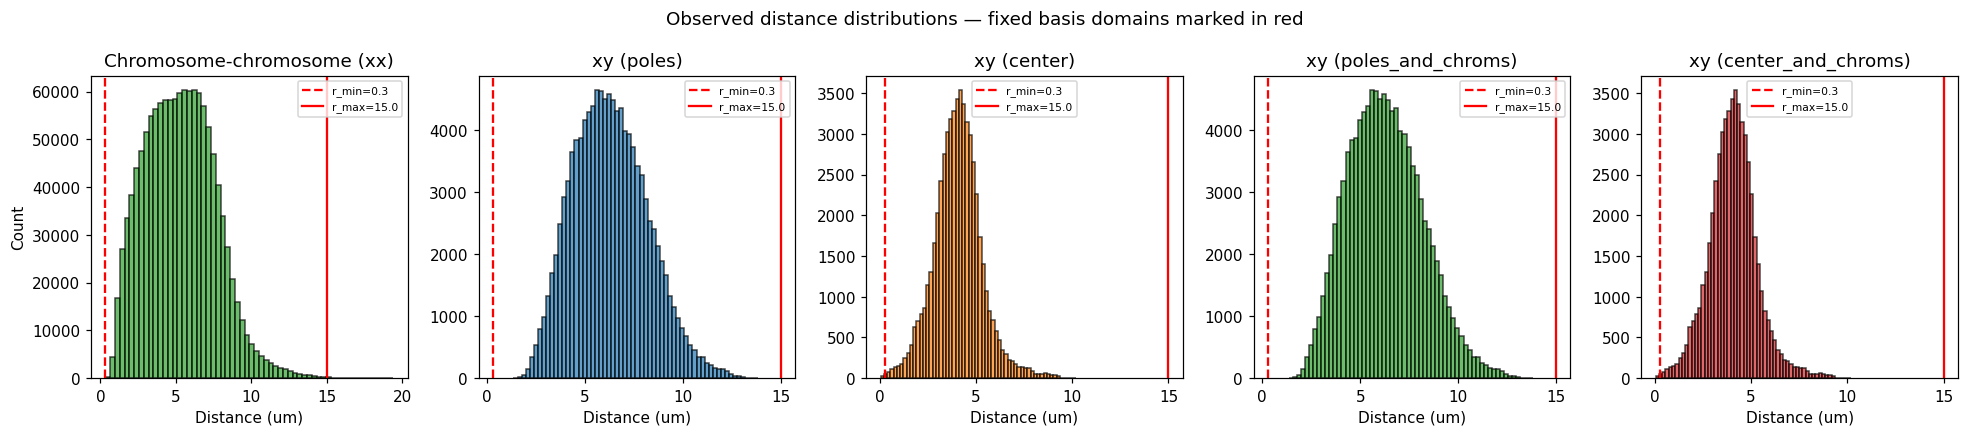

In [5]:
# Only plot unique xy partner sets (poles_and_chroms_enveloped shares partners
# with poles_and_chroms, so skip its duplicate histogram).
_HIST_TOPOLOGIES = [t for t in TOPOLOGIES if t != "poles_and_chroms_enveloped"]
fig, axes = plt.subplots(1, 1 + len(_HIST_TOPOLOGIES), figsize=(18, 4))

axes[0].hist(xx_dists_all, bins=60, color="C2", edgecolor="k", alpha=0.7)
axes[0].axvline(R_MIN, color="r", linestyle="--", linewidth=1.5, label=f"r_min={R_MIN}")
axes[0].axvline(R_MAX, color="r", linestyle="-", linewidth=1.5, label=f"r_max={R_MAX}")
axes[0].set_title("Chromosome-chromosome (xx)")
axes[0].set_xlabel("Distance (um)")
axes[0].set_ylabel("Count")
axes[0].legend(fontsize=7)

for idx, topology in enumerate(_HIST_TOPOLOGIES):
    ax = axes[idx + 1]
    ax.hist(xy_dists_by_topology[topology], bins=60, color=f"C{idx}", edgecolor="k", alpha=0.7)
    ax.axvline(R_MIN, color="r", linestyle="--", linewidth=1.5, label=f"r_min={R_MIN}")
    ax.axvline(R_MAX, color="r", linestyle="-", linewidth=1.5, label=f"r_max={R_MAX}")
    ax.set_title(f"xy ({topology})")
    ax.set_xlabel("Distance (um)")
    ax.legend(fontsize=7)

fig.suptitle("Observed distance distributions — fixed basis domains marked in red")
fig.tight_layout()
plt.show()

## Fit all five models

We use:
- `n_basis = 10` B-spline basis functions for both xx and xy kernels
- `lambda_ridge = 1e-6` (numerical jitter), `lambda_rough = 1.0`
- `basis_eval_mode = "ito"` (current positions, standard SFI)
- `endpoint_frac = 0.4` of the NEB-to-AO window

Domain parameters are fixed a priori (see basis-domain section above).

In [6]:
configs: dict[str, FitConfig] = {}
for topology in TOPOLOGIES:
    use_envelope = topology == "poles_and_chroms_enveloped"
    configs[topology] = FitConfig(
        topology=_base_topology(topology),
        n_basis_xx=N_BASIS,
        n_basis_xy=N_BASIS,
        r_min_xx=R_MIN,
        r_max_xx=R_MAX,
        r_min_xy=R_MIN,
        r_max_xy=R_MAX,
        basis_type=BASIS_TYPE,
        lambda_ridge=LAMBDA_RIDGE,
        lambda_rough=LAMBDA_ROUGH,
        basis_eval_mode=BASIS_EVAL_MODE,
        endpoint_method="neb_ao_frac",
        endpoint_frac=FRAC_NEB_AO_WINDOW,
        dt=DT,
        envelope_r0_xx=ENVELOPE_R0_XX if use_envelope else None,
        envelope_w_xx=ENVELOPE_W_XX if use_envelope else None,
    )

print("Fitting models...")
models: dict[str, FittedModel] = {}
for topology in TOPOLOGIES:
    models[topology] = fit_model(cells, configs[topology])
    m = models[topology]
    print(f"  {topology:<22}  D_x={m.D_x:.8f} um^2/s  "
          f"n_params={m.theta.size}")

Fitting models...


  poles                   D_x=0.00197338 um^2/s  n_params=10


  center                  D_x=0.00196832 um^2/s  n_params=10


  poles_and_chroms        D_x=0.00195569 um^2/s  n_params=20


  center_and_chroms       D_x=0.00195996 um^2/s  n_params=20


  poles_and_chroms_enveloped  D_x=0.00197092 um^2/s  n_params=20


## Cross-validation comparison

Leave-one-cell-out CV: fit on N-1 cells, evaluate mean squared error on the
held-out cell.  Lower is better.

**Secondary short-horizon diagnostic**: leave-one-cell-out one-step velocity
MSE, averaged equally across held-out cells.  Paired fold-by-fold loss
differences and their SEs are reported to assess whether score gaps between
topologies are meaningful.

In [7]:
print(f"Running leave-one-cell-out cross-validation ({len(TOPOLOGIES)} topologies × {len(cells)} folds)...")
cv_results: dict[str, CVResult] = {}
for topology in TOPOLOGIES:
    cv_results[topology] = cross_validate(cells, configs[topology])
    r = cv_results[topology]
    print(f"  {topology:<22}  MSE={r.mean_error:.8f}  (fold SD={r.fold_sd:.8f}, SE={r.fold_se:.8f})")

Running leave-one-cell-out cross-validation (5 topologies × 12 folds)...


  poles                   MSE=0.00077667  (fold SD=0.00023385, SE=0.00006751)


  center                  MSE=0.00077469  (fold SD=0.00023393, SE=0.00006753)


  poles_and_chroms        MSE=0.00077118  (fold SD=0.00023174, SE=0.00006690)


  center_and_chroms       MSE=0.00077261  (fold SD=0.00023318, SE=0.00006731)


  poles_and_chroms_enveloped  MSE=0.00077577  (fold SD=0.00023347, SE=0.00006740)


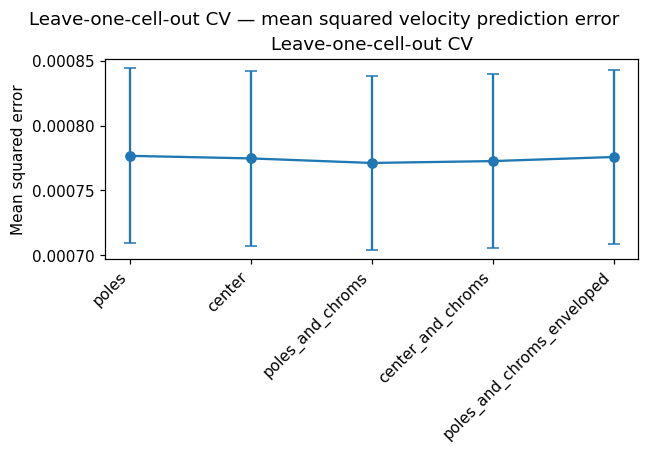

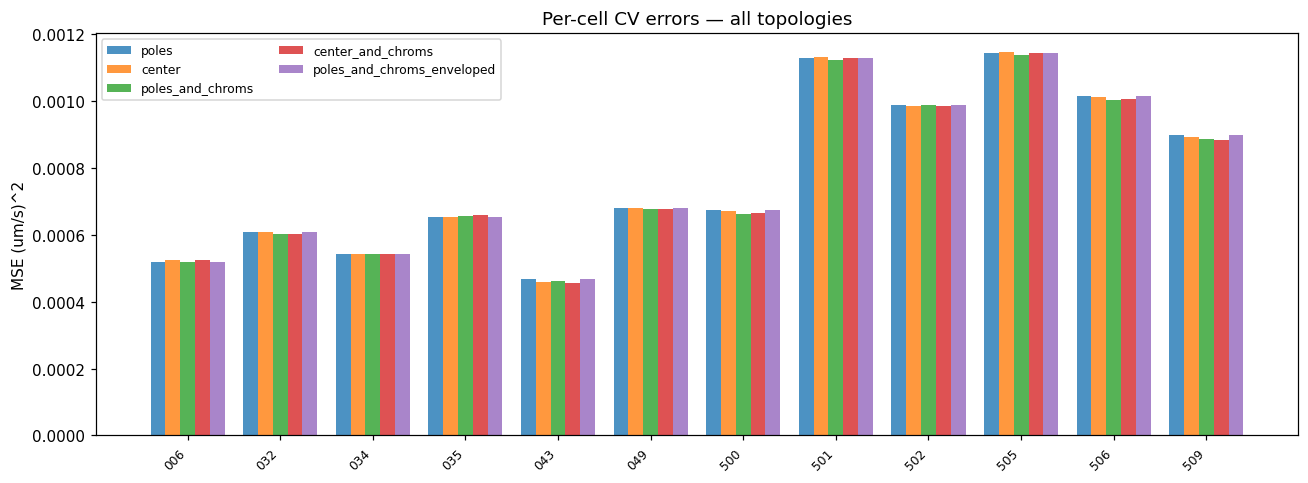


CV summary (sorted by mean MSE):
  #1  poles_and_chroms        MSE=0.00077118  (Δbest=+0.00e+00, SE=6.69e-05)
  #2  center_and_chroms       MSE=0.00077261  (Δbest=+1.43e-06, SE=6.73e-05)
  #3  center                  MSE=0.00077469  (Δbest=+3.51e-06, SE=6.75e-05)
  #4  poles_and_chroms_enveloped  MSE=0.00077577  (Δbest=+4.59e-06, SE=6.74e-05)
  #5  poles                   MSE=0.00077667  (Δbest=+5.49e-06, SE=6.75e-05)


In [8]:
fig = plot_cv_curve(cv_results)
fig.suptitle("Leave-one-cell-out CV — mean squared velocity prediction error", y=1.02)
plt.show()

# Bar chart with per-cell breakdown
n_topo = len(TOPOLOGIES)
n_cells = len(cells)
x = np.arange(n_cells)
width = 0.8 / n_topo

fig, ax = plt.subplots(figsize=(12, 4.5))
for idx, topology in enumerate(TOPOLOGIES):
    offset = (idx - n_topo / 2 + 0.5) * width
    ax.bar(x + offset, cv_results[topology].held_out_errors, width,
           label=topology, alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([c.cell_id.split("_")[-1] for c in cells], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("MSE (um/s)^2")
ax.set_title("Per-cell CV errors — all topologies")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

# Summary printout
print("\nCV summary (sorted by mean MSE):")
sorted_topo_cv = sorted(TOPOLOGIES, key=lambda t: cv_results[t].mean_error)
best_cv = cv_results[sorted_topo_cv[0]].mean_error
for rank, topology in enumerate(sorted_topo_cv):
    r = cv_results[topology]
    delta = r.mean_error - best_cv
    print(f"  #{rank + 1}  {topology:<22}  MSE={r.mean_error:.8f}  "
          f"(Δbest={delta:+.2e}, SE={r.fold_se:.2e})")

## Interpreting the one-step CV scale

The absolute LOOCV MSE values are small because one-frame chromosome
velocities are small and strongly noise-dominated. To calibrate the scale, we
compare the fitted models against two simple references:

- **Zero-velocity baseline**: predict `v = 0` for every held-out coordinate.
- **Diffusion floor**: for overdamped Langevin motion, the per-coordinate
  one-step noise variance is approximately `2 D_x / dt`.

If the fitted models sit close to these references, then one-step CV is still
a sensible primary score, but it should not be expected to sharply separate
topologies on its own.

In [9]:
ref_cfg = configs[TOPOLOGIES[0]]
baseline_basis_xy = BSplineBasis(R_MIN, R_MAX, N_BASIS)
zero_baseline_errors = np.full(len(cells), np.nan, dtype=np.float64)
held_out_abs_vel = np.full(len(cells), np.nan, dtype=np.float64)

for held_out_index, cell in enumerate(cells):
    _, V_test = build_design_matrix(
        [cell],
        basis_xx=None,
        basis_xy=baseline_basis_xy,
        basis_eval_mode=ref_cfg.basis_eval_mode,
        topology="poles",
    )
    if V_test.size == 0:
        continue
    zero_baseline_errors[held_out_index] = float(np.mean(V_test**2))
    held_out_abs_vel[held_out_index] = float(np.mean(np.abs(V_test)))

zero_baseline_mean = float(np.nanmean(zero_baseline_errors))
zero_baseline_rmse = float(np.sqrt(zero_baseline_mean))
mean_abs_velocity = float(np.nanmean(held_out_abs_vel))
noise_floor = {
    topology: 2.0 * models[topology].D_x / configs[topology].dt
    for topology in TOPOLOGIES
}

print("\n1-step CV scale check")
print("=" * 116)
print(f"Zero-velocity baseline: MSE={zero_baseline_mean:.8f}  RMSE={zero_baseline_rmse:.5f} um/s")
print(f"Mean held-out |v|:      {mean_abs_velocity:.5f} um/s")
print("-" * 116)
print(f"{'Topology':<22} {'CV MSE':>12} {'impr vs 0':>11} {'Δ vs 0':>10} {'2D/dt':>12} {'CV/(2D/dt)':>12}")
print("-" * 116)
for topology in sorted_topo_cv:
    cv = cv_results[topology].mean_error
    gain = zero_baseline_mean - cv
    gain_pct = 100.0 * gain / zero_baseline_mean if zero_baseline_mean > 0 else np.nan
    floor = noise_floor[topology]
    ratio = cv / floor if floor > 0 else np.nan
    print(f"  {topology:<22} {cv:>12.8f} {gain_pct:>+10.2f}% {gain:>10.2e} {floor:>12.8f} {ratio:>12.3f}")
print("=" * 116)
print("These one-step losses are close to both the zero-velocity baseline and the diffusion-noise floor.")
print("So the primary CV score is sensible, but in this dataset it only weakly separates the topologies.")


1-step CV scale check
Zero-velocity baseline: MSE=0.00078681  RMSE=0.02805 um/s
Mean held-out |v|:      0.02011 um/s
--------------------------------------------------------------------------------------------------------------------
Topology                     CV MSE   impr vs 0     Δ vs 0        2D/dt   CV/(2D/dt)
--------------------------------------------------------------------------------------------------------------------
  poles_and_chroms         0.00077118      +1.99%   1.56e-05   0.00078228        0.986
  center_and_chroms        0.00077261      +1.80%   1.42e-05   0.00078398        0.985
  center                   0.00077469      +1.54%   1.21e-05   0.00078733        0.984
  poles_and_chroms_enveloped   0.00077577      +1.40%   1.10e-05   0.00078837        0.984
  poles                    0.00077667      +1.29%   1.01e-05   0.00078935        0.984
These one-step losses are close to both the zero-velocity baseline and the diffusion-noise floor.
So the primary CV score is

## Bootstrap kernel confidence bands

N cell-level resamples per topology; shaded band = 5–95% quantile interval.

In [10]:
N_BOOT = 100
boot_rng = np.random.default_rng(42)

print(f"Bootstrapping kernels ({N_BOOT} resamples × {len(TOPOLOGIES)} topologies)...")
boot_results: dict[str, BootstrapResult] = {}
for topology in TOPOLOGIES:
    boot_results[topology] = bootstrap_kernels(
        cells, configs[topology], n_boot=N_BOOT, rng=boot_rng
    )
    print(f"  {topology} done.")

Bootstrapping kernels (100 resamples × 5 topologies)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    2.9s


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    5.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


  poles done.


...

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   15.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


  center_and_chroms done.


[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    4.8s


  poles_and_chroms_enveloped done.


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   16.9s finished


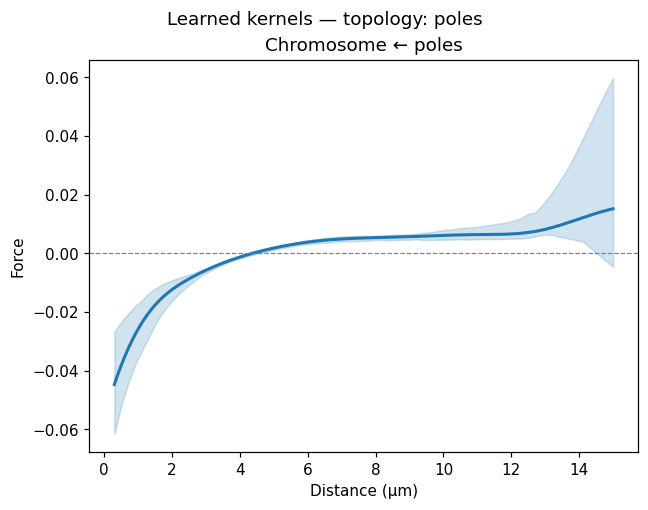

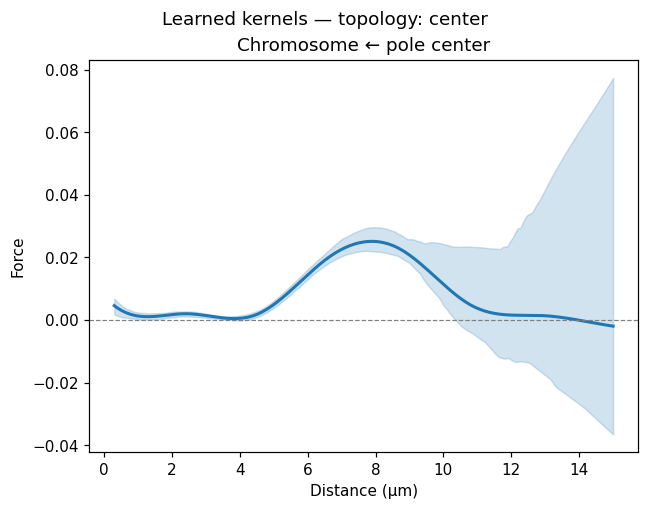

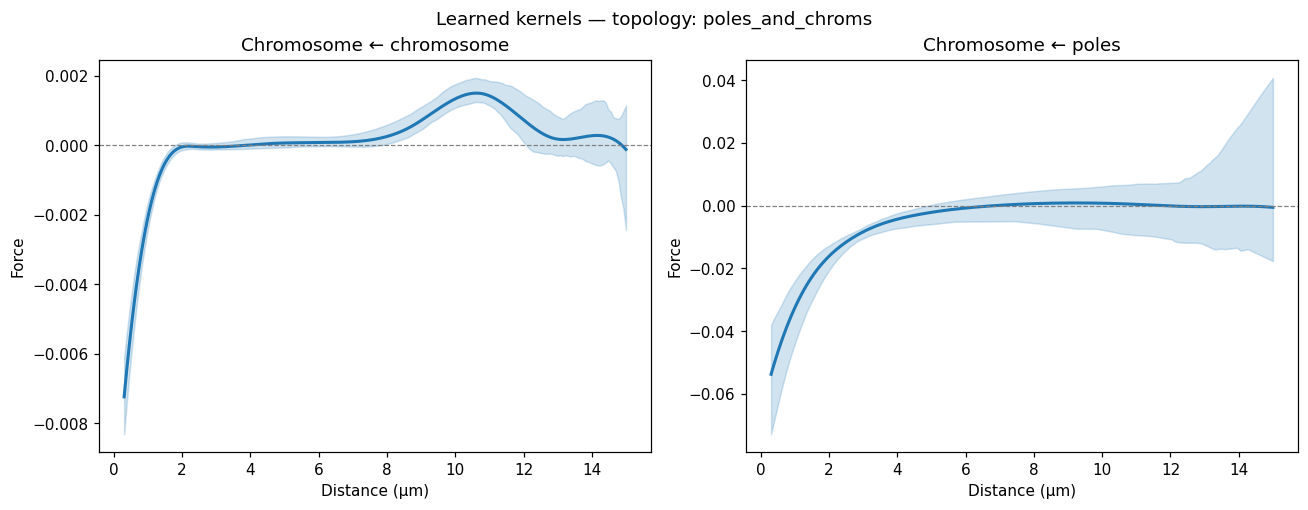

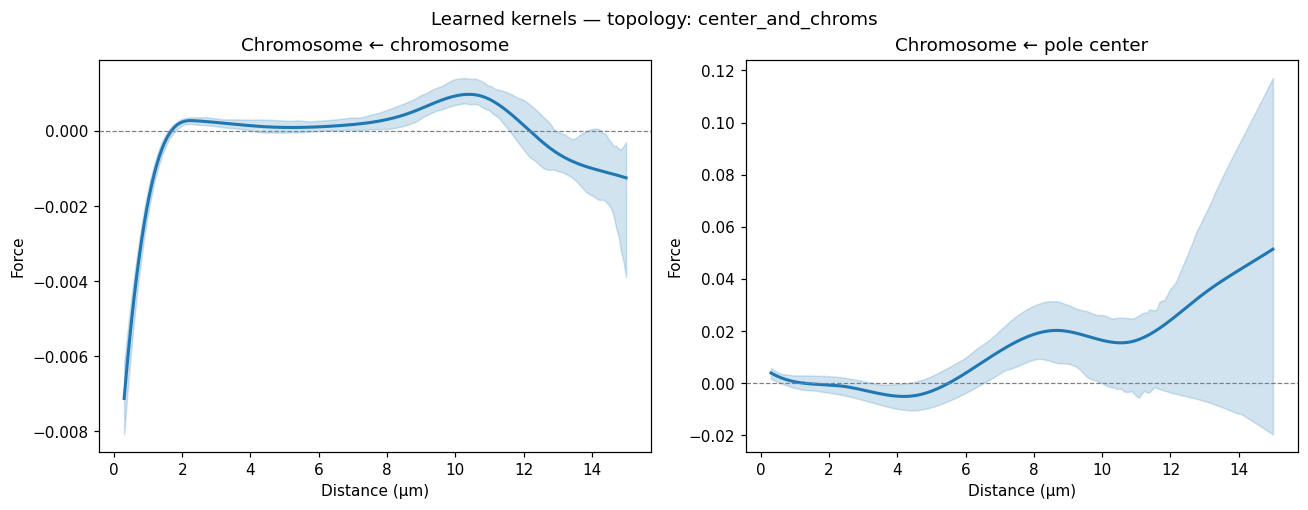

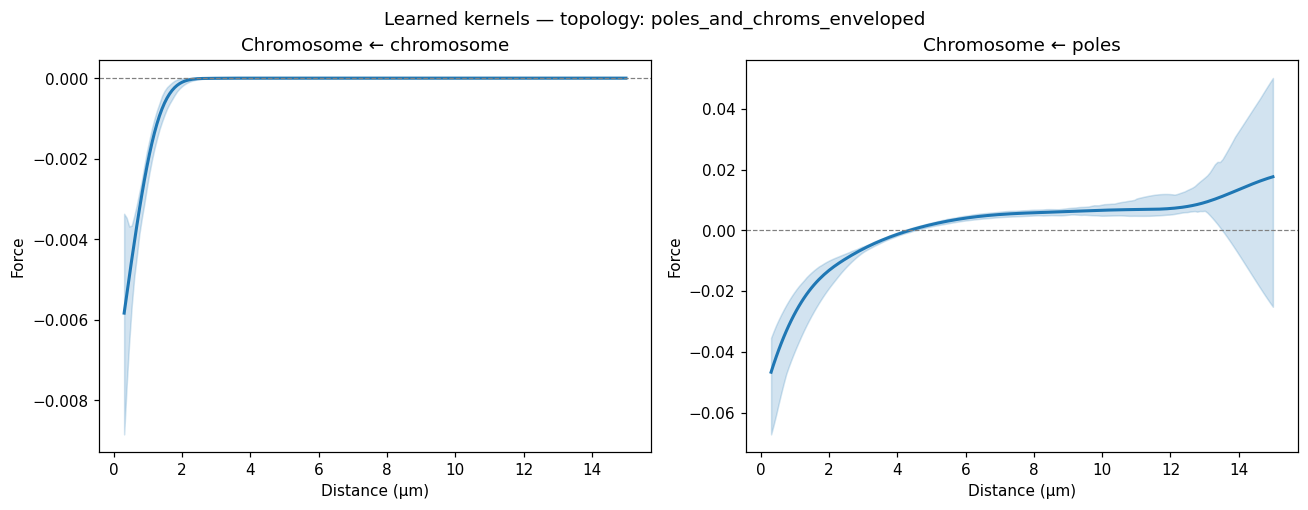

In [11]:
# Plot each topology's kernels with bootstrap bands
for topology in TOPOLOGIES:
    fig = plot_kernels(models[topology], bootstrap=boot_results[topology])
    fig.suptitle(f"Learned kernels — topology: {topology}", y=1.02)
    plt.show()

## Physical plausibility of the chromosome-chromosome kernel

For topologies that include a chromosome-chromosome term (`poles_and_chroms`
and `center_and_chroms`), we inspect whether the learned kernel is
physically sensible:

- Sign convention: forces are assembled as `f(r) * (x_j - x_i) / r`, so
  positive values are attractive and negative values are repulsive.
- **Expected**: a repulsive barrier at short distances (excluded volume,
  r ≲ 1 um), i.e. negative `f_xx(r)` at small `r`.
- **Red flag**: short-range attraction (positive force at small `r`), which
  would pull chromosomes into one another.

We flag any model where f_xx at r < 1.5 um becomes positive.

  [OK] poles_and_chroms: f_xx is repulsive or neutral at short range (max=-0.0005 at r < 1.5 um).
  [OK] center_and_chroms: f_xx is repulsive or neutral at short range (max=-0.0003 at r < 1.5 um).
  [OK] poles_and_chroms_enveloped: f_xx is repulsive or neutral at short range (max=-0.0006 at r < 1.5 um).


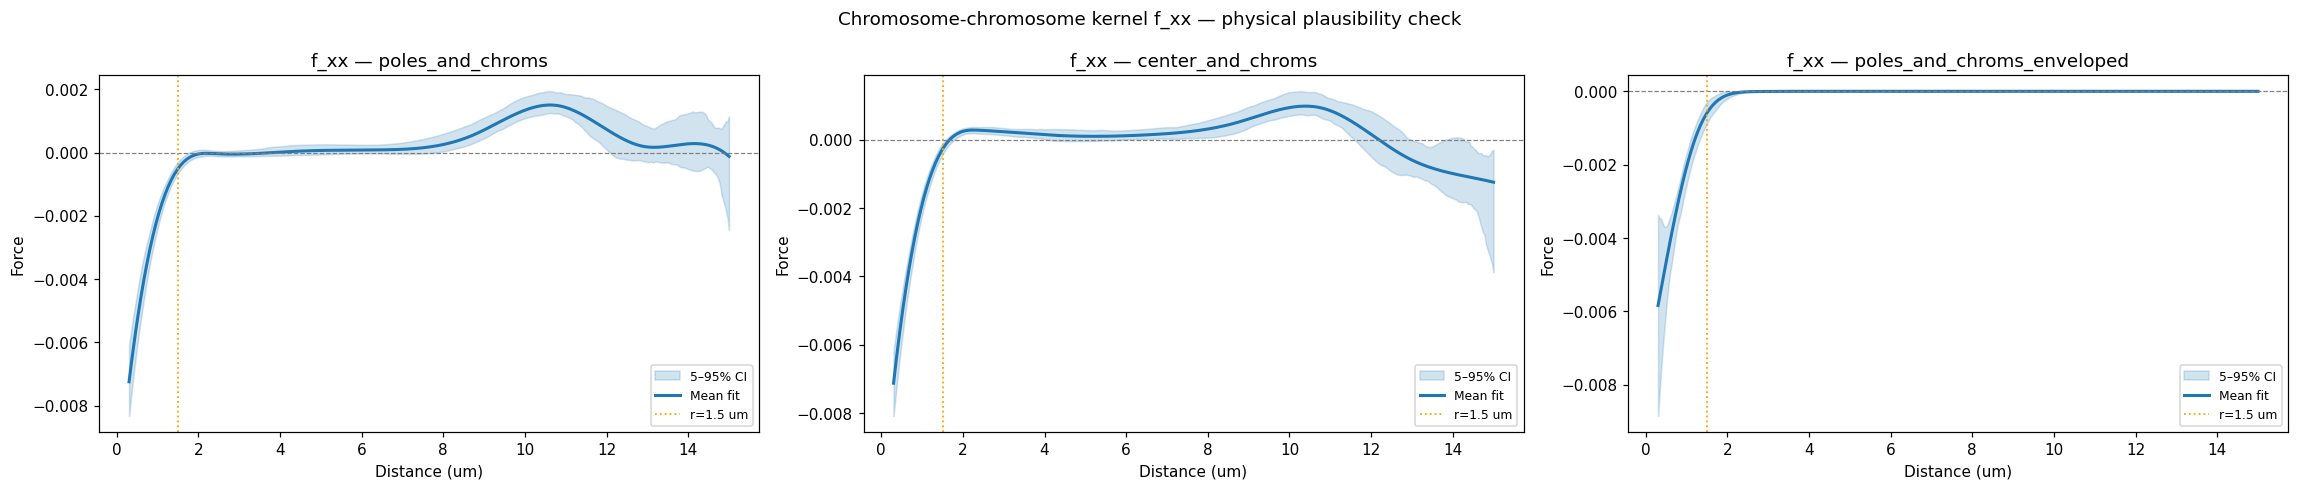

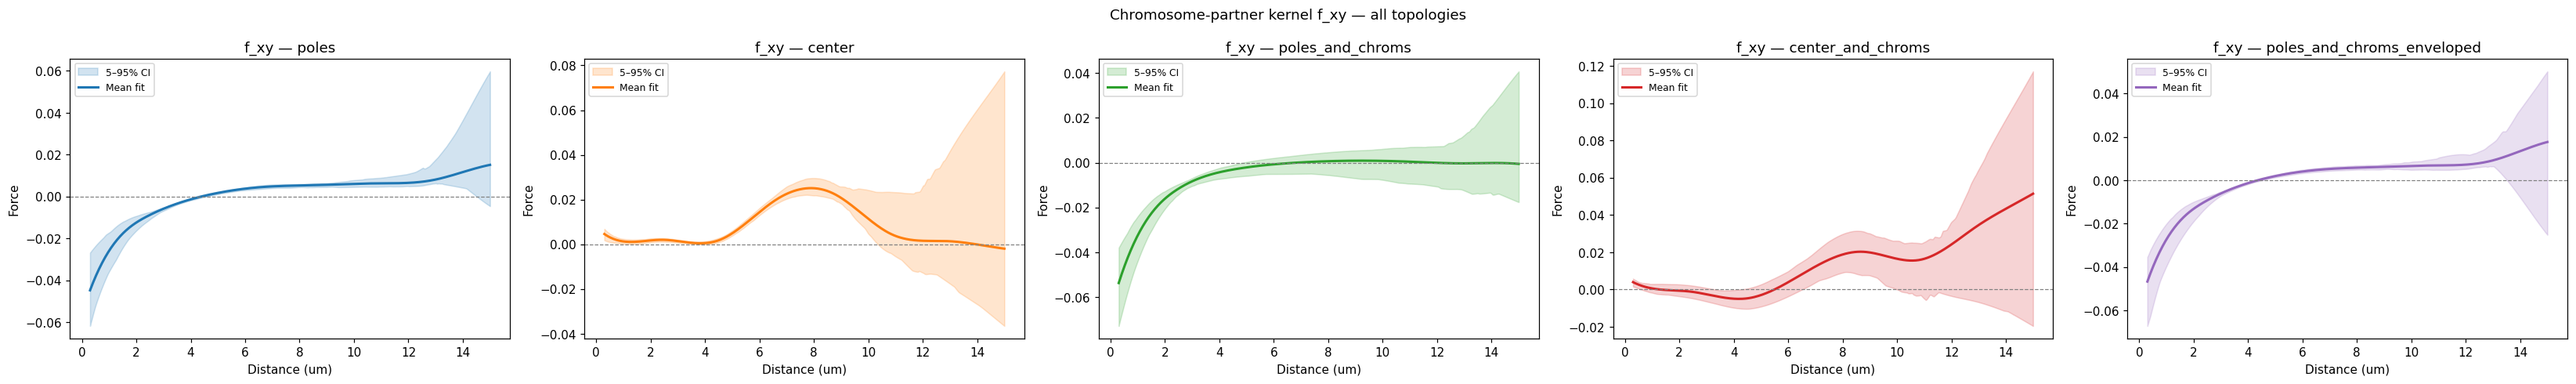

In [12]:
chroms_topologies = [t for t in TOPOLOGIES if "chroms" in t]
r_probe = np.linspace(r_min_xx, r_max_xx, 400)
SHORT_R_THRESHOLD = 1.5  # um — below this we expect repulsion, not attraction

fig, axes = plt.subplots(1, len(chroms_topologies), figsize=(7 * len(chroms_topologies), 4.5),
                          squeeze=False)

for col, topology in enumerate(chroms_topologies):
    ax = axes[0, col]
    m = models[topology]
    boot = boot_results[topology]

    f_vals = m.evaluate_kernel("xx", r_probe)

    # Bootstrap band — basis_xx.evaluate already includes the smooth envelope
    # for the enveloped variant, so the CI tracks the effective kernel without
    # any manual zeroing.
    phi = m.basis_xx.evaluate(r_probe)
    theta_xx_samples = boot.theta_samples[:, : m.n_basis_xx]
    curves = phi @ theta_xx_samples.T
    lo = np.percentile(curves, 5, axis=1)
    hi = np.percentile(curves, 95, axis=1)
    ax.fill_between(r_probe, lo, hi, color="C0", alpha=0.2, label="5–95% CI")

    ax.plot(r_probe, f_vals, "C0", linewidth=2, label="Mean fit")
    ax.axhline(0.0, color="0.5", linestyle="--", linewidth=0.8)
    ax.axvline(SHORT_R_THRESHOLD, color="orange", linestyle=":", linewidth=1.2,
               label=f"r={SHORT_R_THRESHOLD} um")
    ax.set_xlabel("Distance (um)")
    ax.set_ylabel("Force")
    ax.set_title(f"f_xx — {topology}")
    ax.legend(fontsize=8)

    # Diagnosis
    short_r_mask = r_probe < SHORT_R_THRESHOLD
    max_short_r = float(np.max(f_vals[short_r_mask])) if short_r_mask.any() else np.nan
    if max_short_r > 0:
        print(f"  [WARNING] {topology}: f_xx is ATTRACTIVE at short range "
              f"(max={max_short_r:.4f} at r < {SHORT_R_THRESHOLD} um). "
              "Likely an artifact — excluded-volume physics expects repulsion here.")
    else:
        print(f"  [OK] {topology}: f_xx is repulsive or neutral at short range "
              f"(max={max_short_r:.4f} at r < {SHORT_R_THRESHOLD} um).")

fig.suptitle("Chromosome-chromosome kernel f_xx — physical plausibility check")
fig.tight_layout()
plt.show()

# Also plot f_xy for chroms topologies alongside poles/center for comparison
fig, axes = plt.subplots(1, len(TOPOLOGIES), figsize=(6 * len(TOPOLOGIES), 4.5), squeeze=False)
r_xy_probe = {t: np.linspace(R_MIN, R_MAX, 400) for t in TOPOLOGIES}

for col, topology in enumerate(TOPOLOGIES):
    ax = axes[0, col]
    m = models[topology]
    boot = boot_results[topology]
    r_p = r_xy_probe[topology]

    f_vals = m.evaluate_kernel("xy", r_p)
    phi = m.basis_xy.evaluate(r_p)
    theta_xy_samples = boot.theta_samples[:, m.n_basis_xx:]
    curves = phi @ theta_xy_samples.T
    lo = np.percentile(curves, 5, axis=1)
    hi = np.percentile(curves, 95, axis=1)

    ax.fill_between(r_p, lo, hi, color=f"C{col}", alpha=0.2, label="5–95% CI")
    ax.plot(r_p, f_vals, f"C{col}", linewidth=2, label="Mean fit")
    ax.axhline(0.0, color="0.5", linestyle="--", linewidth=0.8)
    ax.set_xlabel("Distance (um)")
    ax.set_ylabel("Force")
    ax.set_title(f"f_xy — {topology}")
    ax.legend(fontsize=8)

fig.suptitle("Chromosome-partner kernel f_xy — all topologies")
fig.tight_layout()
plt.show()

## Rollout validation: qualitative cells and aggregate holdout scoring

One-step CV is useful for local velocity prediction, but it does not tell us
whether a fitted model generates plausible chromosome trajectories when run
forward.  We therefore look at rollout validation in two complementary ways:

1. A few representative cells with **one simulated rollout per model** to
   inspect whether the simulated trajectories qualitatively resemble the real
   spindle-frame traces.
2. **Leave-one-cell-out rollout validation** that aggregates across all cells
   and scores axial/radial summary trajectories and final-frame
   distributions.

Notes for interpretation:

- In the qualitative plots below, the thick curves are means over **all**
  chromosomes. The thin colored lines show only a small displayed subset.
- For the `poles` topologies, symmetric attraction to the two poles does **not**
  automatically imply centering at the spindle midpoint. If attraction
  weakens with distance, the nearer pole wins and the midpoint is not a
  stable fixed point.
- If a `center` topology still drifts axially in rollout, that usually means
  the learned attraction to the moving spindle center is too weak to keep up
  with the real partner motion, not necessarily that there is a sign bug.

Qualitative rollout check on representative cells (1 rollout per model)...
  rpe18_ctr_006: 85 frames, 46 chromosomes


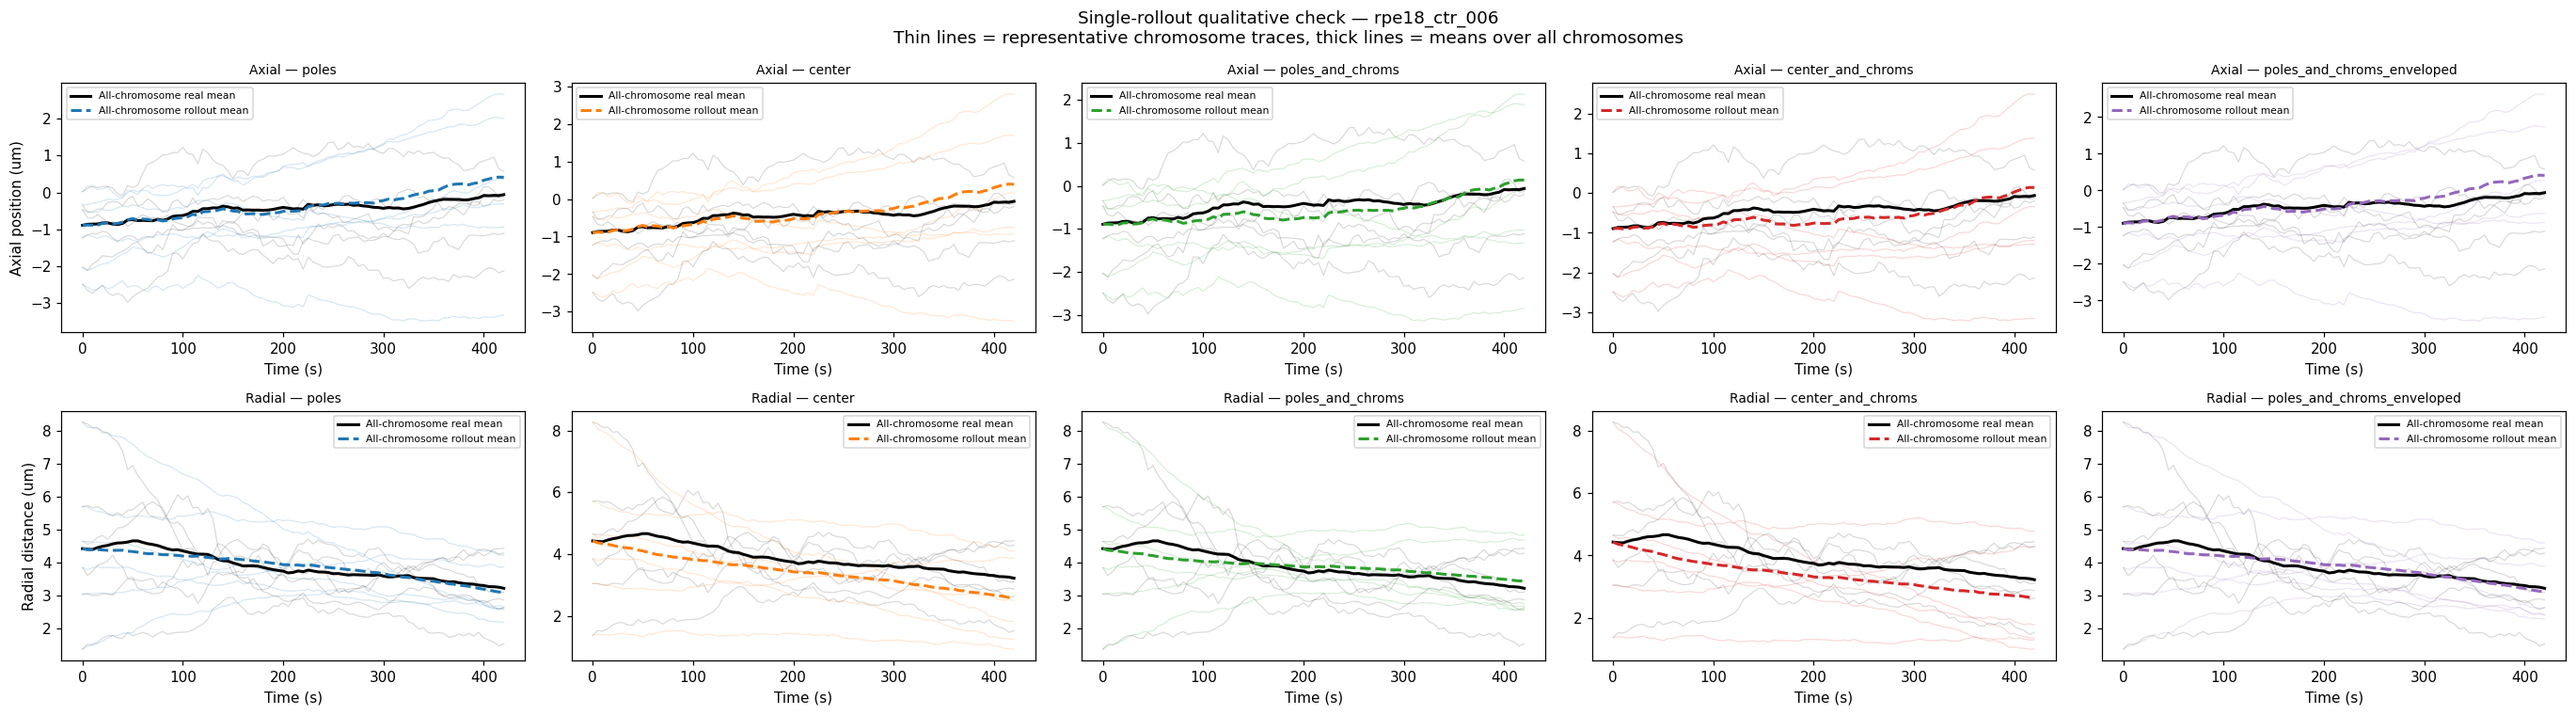

  rpe18_ctr_500: 127 frames, 46 chromosomes


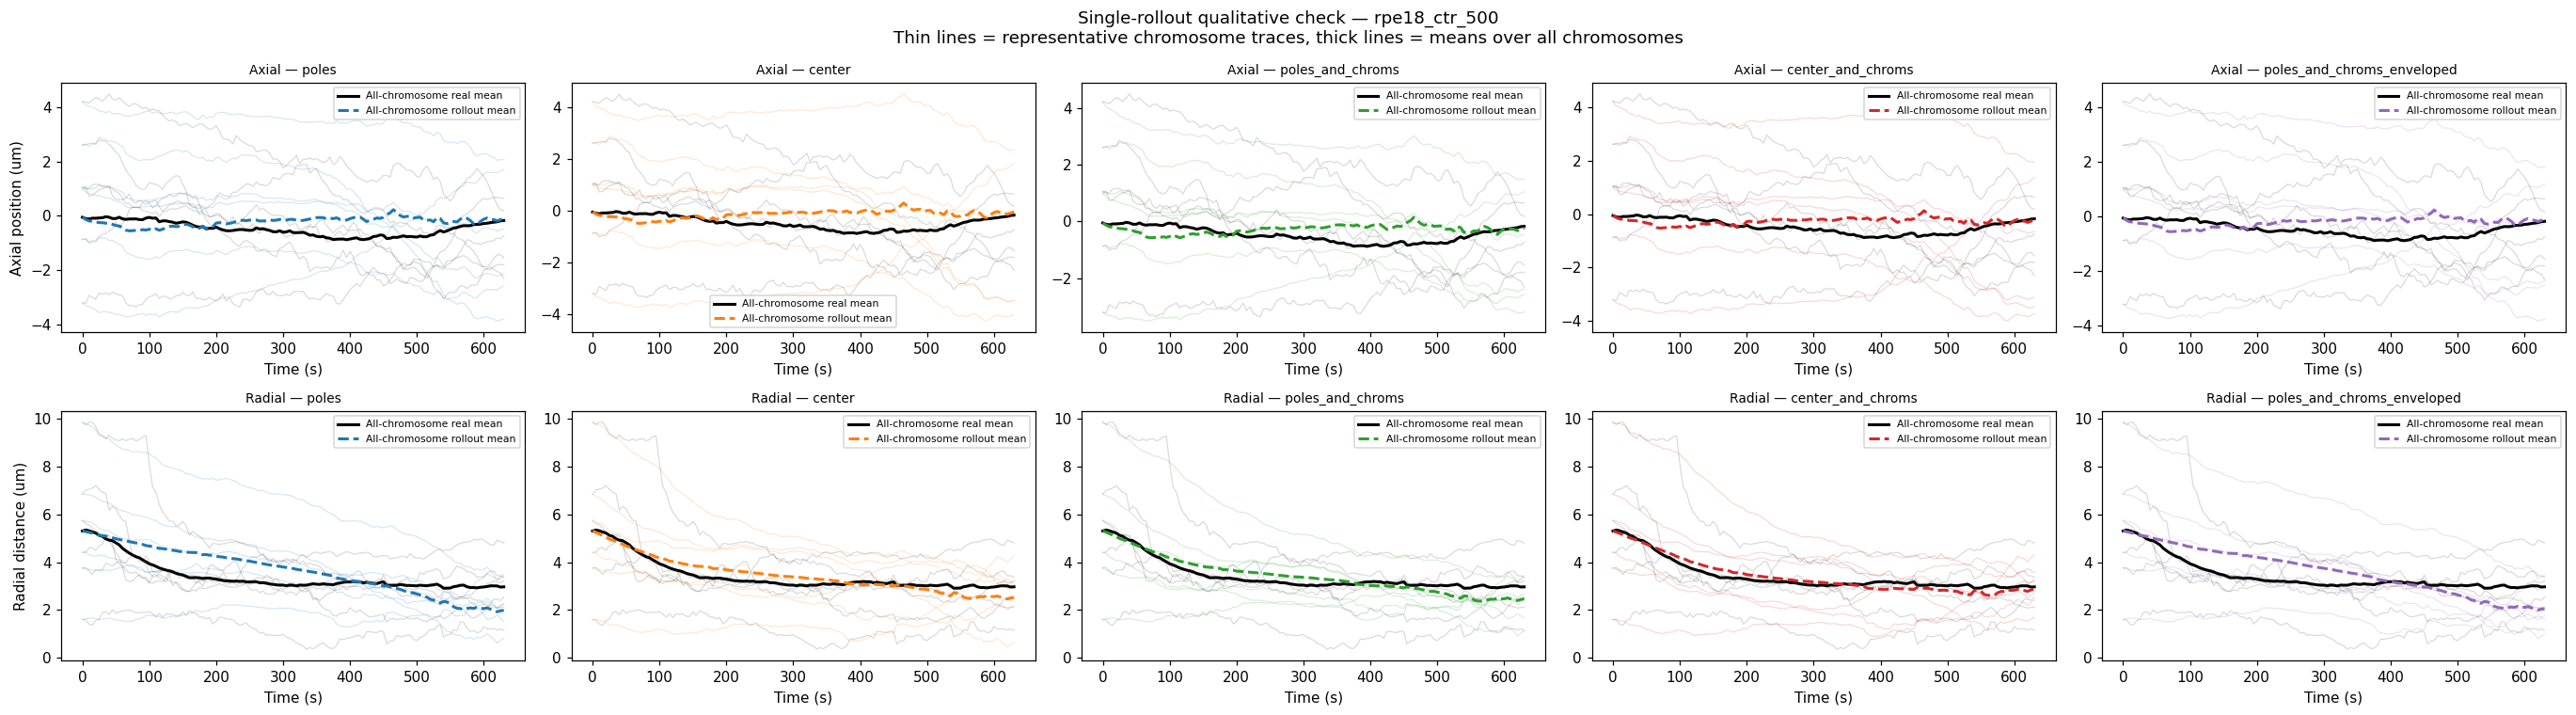

  rpe18_ctr_509: 125 frames, 46 chromosomes


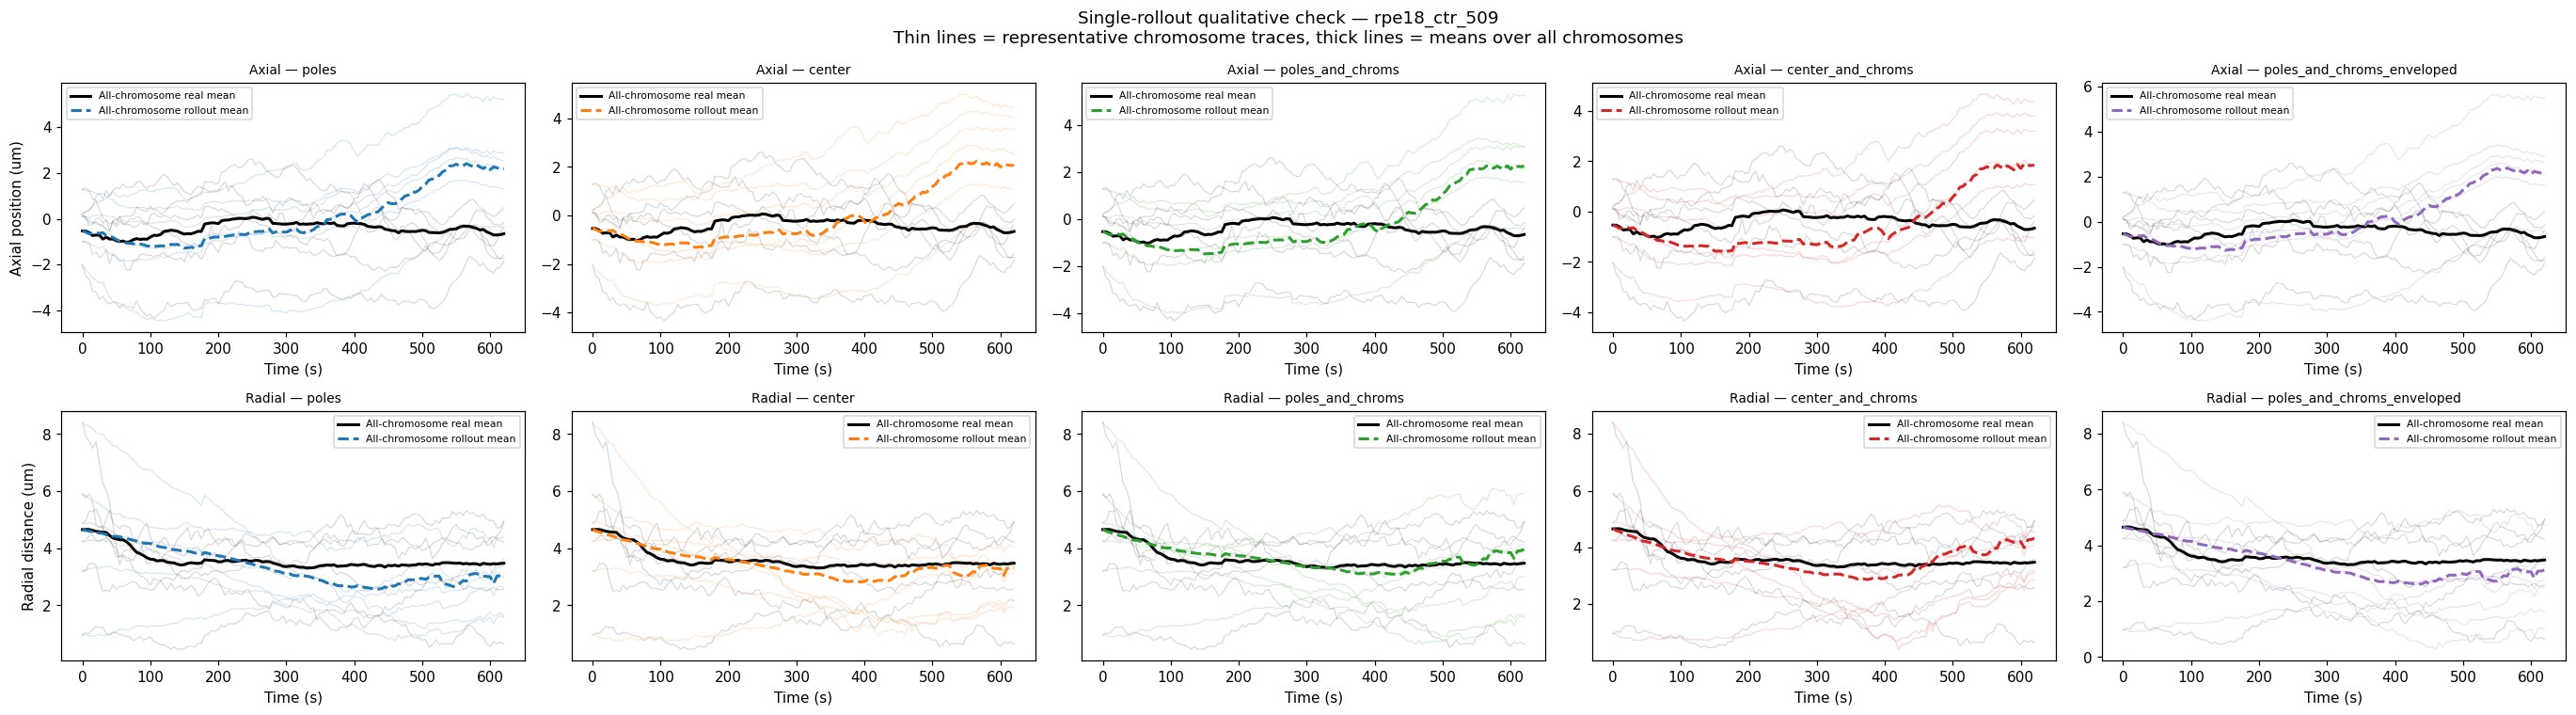

In [13]:
EXAMPLE_CELL_IDX = 1
example_cell = cells[EXAMPLE_CELL_IDX]
T, _, N_chrom = example_cell.chromosomes.shape
n_steps = T - 1
x0 = example_cell.chromosomes[0].T
sf_real = spindle_frame(example_cell)

QUAL_CELL_IDXS = sorted({0, len(cells) // 2, len(cells) - 1})
QUAL_N_TRACES = 6
ROLLOUT_HORIZONS = (1, 3, 5, 8, 10, 15, 20, 25, 30)
H_PRIMARY = 10  # Diagnostic forecast horizon (frames; Alex's docx anchor).
                # Used for the supporting horizon-resolved curve and h=10 ensemble
                # MSE diagnostic.  Primary criterion is path MSE over the full
                # trimmed window; see model-selection summary below.
assert H_PRIMARY in ROLLOUT_HORIZONS, "H_PRIMARY must be one of ROLLOUT_HORIZONS"


def _simulate_cell_once(cell: TrimmedCell, model: FittedModel, seed: int = 0,
                         deterministic: bool = True):
    rng = None if deterministic else np.random.default_rng(seed)
    traj, sim_cell = simulate_cell(cell, model, rng=rng, deterministic=deterministic)
    return traj, spindle_frame(sim_cell)


def _representative_trace_indices(sf_data, n_traces: int) -> np.ndarray:
    valid = np.flatnonzero(
        np.all(np.isfinite(sf_data.axial), axis=0)
        & np.all(np.isfinite(sf_data.radial), axis=0)
    )
    if valid.size == 0:
        return valid
    if valid.size <= n_traces:
        return valid

    # Spread displayed traces across the initial radial distribution so the
    # thin-line examples are less biased than "first N valid chromosomes".
    radial0 = sf_data.radial[0, valid]
    order = valid[np.argsort(radial0)]
    positions = np.linspace(0, order.size - 1, n_traces, dtype=int)
    return order[positions]


def _interp_to_unit_grid(values: np.ndarray, n_grid: int = 100) -> np.ndarray:
    values = np.asarray(values, dtype=np.float64)
    if values.size == 0:
        return np.full(n_grid, np.nan, dtype=np.float64)
    if values.size == 1:
        return np.full(n_grid, values[0], dtype=np.float64)
    src = np.linspace(0.0, 1.0, values.size)
    dst = np.linspace(0.0, 1.0, n_grid)
    return np.interp(dst, src, values)


print("Qualitative rollout check on representative cells (1 rollout per model)...")
for cell_idx in QUAL_CELL_IDXS:
    cell = cells[cell_idx]
    sf_cell_real = spindle_frame(cell)
    time_axis = np.arange(cell.chromosomes.shape[0]) * cell.dt
    trace_idx = _representative_trace_indices(sf_cell_real, QUAL_N_TRACES)

    fig, axes = plt.subplots(2, len(TOPOLOGIES), figsize=(5 * len(TOPOLOGIES), 7), squeeze=False)
    print(f"  {cell.cell_id}: {cell.chromosomes.shape[0]} frames, {cell.chromosomes.shape[2]} chromosomes")

    for col, topology in enumerate(TOPOLOGIES):
        _traj, sf_sim = _simulate_cell_once(cell, models[topology])

        ax_axial = axes[0, col]
        ax_radial = axes[1, col]
        color = f"C{col}"

        for chrom_idx in trace_idx:
            ax_axial.plot(time_axis, sf_cell_real.axial[:, chrom_idx], color="k", alpha=0.15, linewidth=0.8)
            ax_axial.plot(time_axis, sf_sim.axial[:, chrom_idx], color=color, alpha=0.18, linewidth=0.8)
            ax_radial.plot(time_axis, sf_cell_real.radial[:, chrom_idx], color="k", alpha=0.15, linewidth=0.8)
            ax_radial.plot(time_axis, sf_sim.radial[:, chrom_idx], color=color, alpha=0.18, linewidth=0.8)

        real_axial_mean = np.nanmean(sf_cell_real.axial, axis=1)
        sim_axial_mean = np.nanmean(sf_sim.axial, axis=1)
        real_radial_mean = np.nanmean(sf_cell_real.radial, axis=1)
        sim_radial_mean = np.nanmean(sf_sim.radial, axis=1)

        ax_axial.plot(time_axis, real_axial_mean, "k-", linewidth=2.0, label="All-chromosome real mean")
        ax_axial.plot(time_axis, sim_axial_mean, color=color, linestyle="--", linewidth=2.0,
                      label="All-chromosome rollout mean")
        ax_radial.plot(time_axis, real_radial_mean, "k-", linewidth=2.0, label="All-chromosome real mean")
        ax_radial.plot(time_axis, sim_radial_mean, color=color, linestyle="--", linewidth=2.0,
                       label="All-chromosome rollout mean")

        ax_axial.set_title(f"Axial — {topology}", fontsize=9)
        ax_radial.set_title(f"Radial — {topology}", fontsize=9)
        ax_axial.set_xlabel("Time (s)")
        ax_radial.set_xlabel("Time (s)")
        if col == 0:
            ax_axial.set_ylabel("Axial position (um)")
            ax_radial.set_ylabel("Radial distance (um)")
        ax_axial.legend(fontsize=7)
        ax_radial.legend(fontsize=7)

    fig.suptitle(f"Single-rollout qualitative check — {cell.cell_id}\n"
                 "Thin lines = representative chromosome traces, thick lines = means over all chromosomes")
    fig.tight_layout()
    plt.show()

### Trajectories in PCA space: real vs rollout

We project real and simulated trajectories into a common 2-component PCA
basis fitted from the **real** cell's combined pole + chromosome positions.
This gives a data-driven 3D→2D view where pole separation and chromosome
spread are both visible.  The same basis is used for both panels so
differences reflect the model, not the projection.

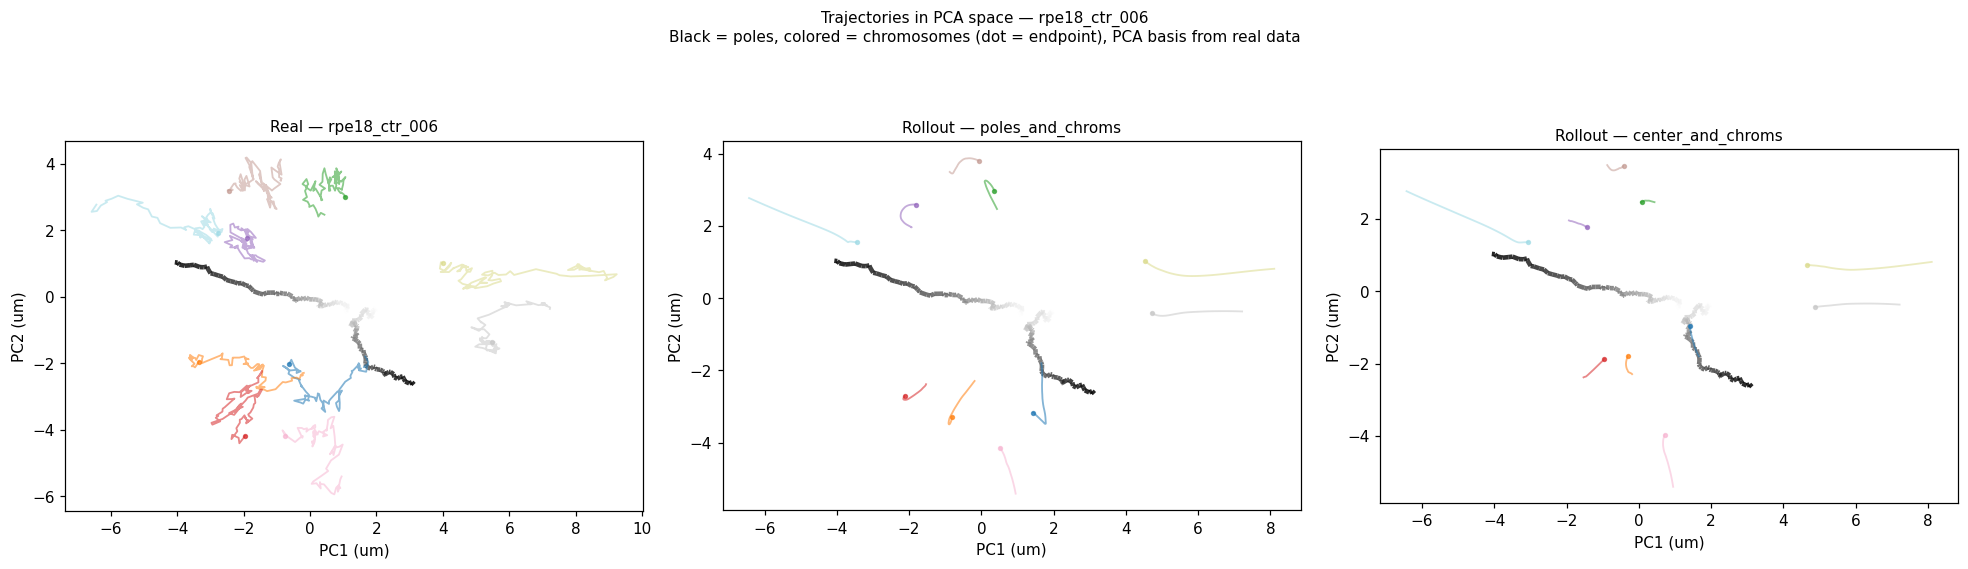

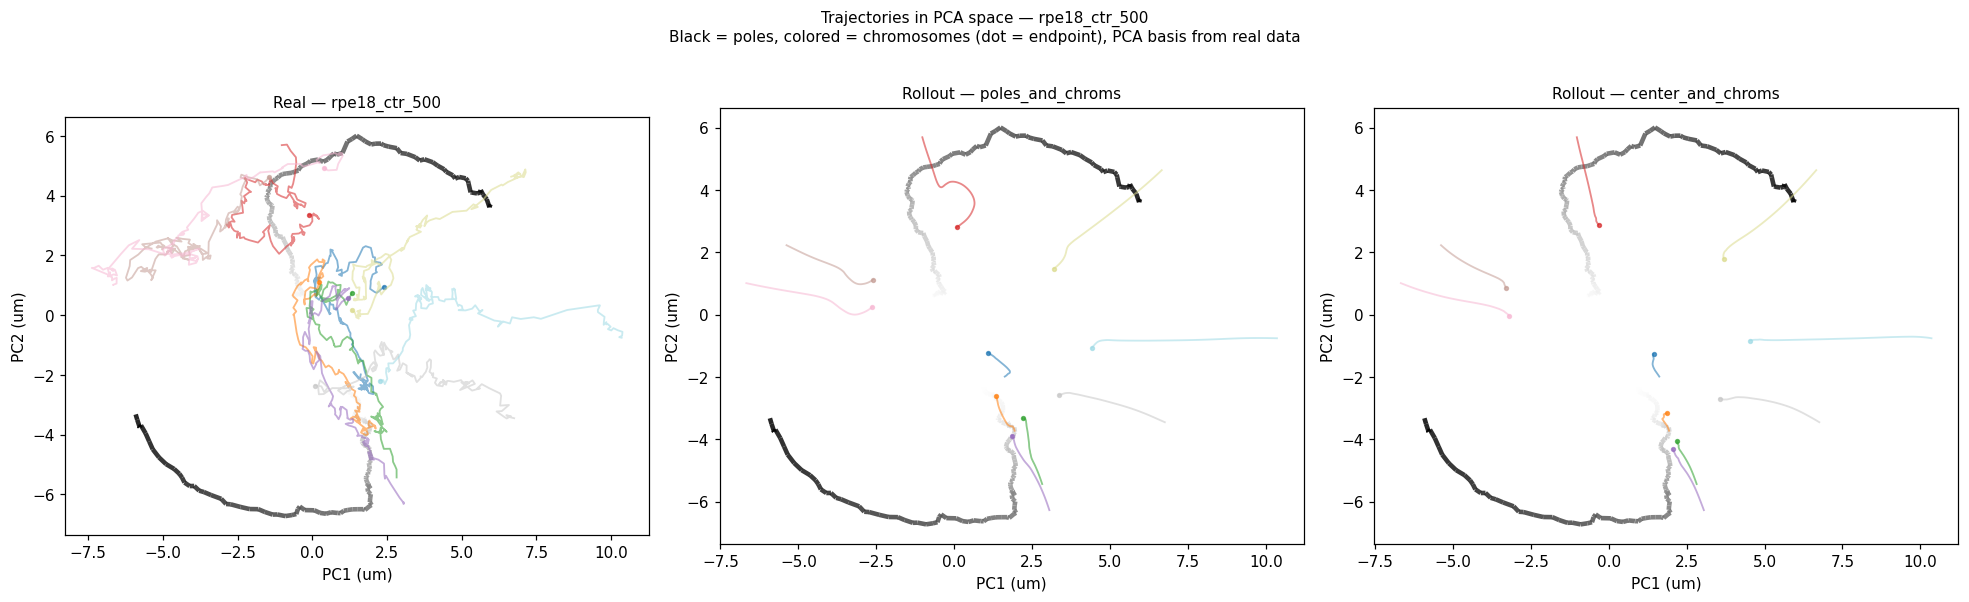

In [14]:
from matplotlib.collections import LineCollection


def _colorline(ax, x, y, t, cmap, linewidth=1.5, alpha=1.0):
    """Plot a line colored by scalar *t* (values in [0, 1])."""
    points = np.column_stack([x, y]).reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, cmap=cmap, linewidths=linewidth, alpha=alpha)
    lc.set_array(t[:-1])
    ax.add_collection(lc)
    return lc


PCA_TOPOLOGIES = sorted_topo_cv[:2]
PCA_N_CHROM_DISPLAY = 10

for cell_idx in QUAL_CELL_IDXS[:2]:
    cell = cells[cell_idx]
    T_cell = cell.chromosomes.shape[0]
    n_chrom = cell.chromosomes.shape[2]
    t_color = np.linspace(0, 1, T_cell)

    basis = fit_pca_basis(cell)

    n_panels = 1 + len(PCA_TOPOLOGIES)
    fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 5.5), squeeze=False)

    # Choose a spread of chromosomes to display (by initial radial position)
    sf_real = spindle_frame(cell)
    valid_chroms = np.flatnonzero(
        np.all(np.isfinite(cell.chromosomes[:, :, :]), axis=(0, 1))
    )
    if valid_chroms.size > PCA_N_CHROM_DISPLAY:
        radial0 = sf_real.radial[0, valid_chroms]
        order = valid_chroms[np.argsort(radial0)]
        display_chroms = order[np.linspace(0, order.size - 1, PCA_N_CHROM_DISPLAY, dtype=int)]
    else:
        display_chroms = valid_chroms

    def _plot_pca_panel(ax, cell_data, title):
        """Plot poles + chromosomes in PCA space on a single axis."""
        # Poles: thick black
        for p in range(cell_data.centrioles.shape[2]):
            pole_pca = basis.project(cell_data.centrioles[:, :, p])
            _colorline(ax, pole_pca[:, 0], pole_pca[:, 1], t_color,
                        "Greys", linewidth=3, alpha=0.85)

        # Chromosomes: thin colored lines
        chrom_cmap = plt.cm.tab20(np.linspace(0, 1, max(len(display_chroms), 1)))
        for ci, j in enumerate(display_chroms):
            cj = cell_data.chromosomes[:, :, j]
            if np.any(np.isnan(cj)):
                continue
            cj_pca = basis.project(cj)
            ax.plot(cj_pca[:, 0], cj_pca[:, 1], color=chrom_cmap[ci],
                    linewidth=1.2, alpha=0.55)
            ax.plot(cj_pca[-1, 0], cj_pca[-1, 1], "o", color=chrom_cmap[ci],
                    markersize=2.5, alpha=0.7)

        ax.set_xlabel("PC1 (um)")
        ax.set_ylabel("PC2 (um)")
        ax.set_title(title, fontsize=10)
        ax.set_aspect("equal")
        ax.autoscale()

    # Panel 0: real data
    _plot_pca_panel(axes[0, 0], cell, f"Real — {cell.cell_id}")

    # Panels 1+: rollouts from selected topologies
    for ti, topology in enumerate(PCA_TOPOLOGIES):
        _traj, sim_cell_3d = simulate_cell(cell, models[topology],
                                           deterministic=True)
        _plot_pca_panel(axes[0, ti + 1], sim_cell_3d, f"Rollout — {topology}")

    fig.suptitle(f"Trajectories in PCA space — {cell.cell_id}\n"
                 "Black = poles, colored = chromosomes (dot = endpoint), "
                 "PCA basis from real data",
                 fontsize=10)
    fig.tight_layout()
    plt.show()

Aggregating full-data forward simulations across all cells...


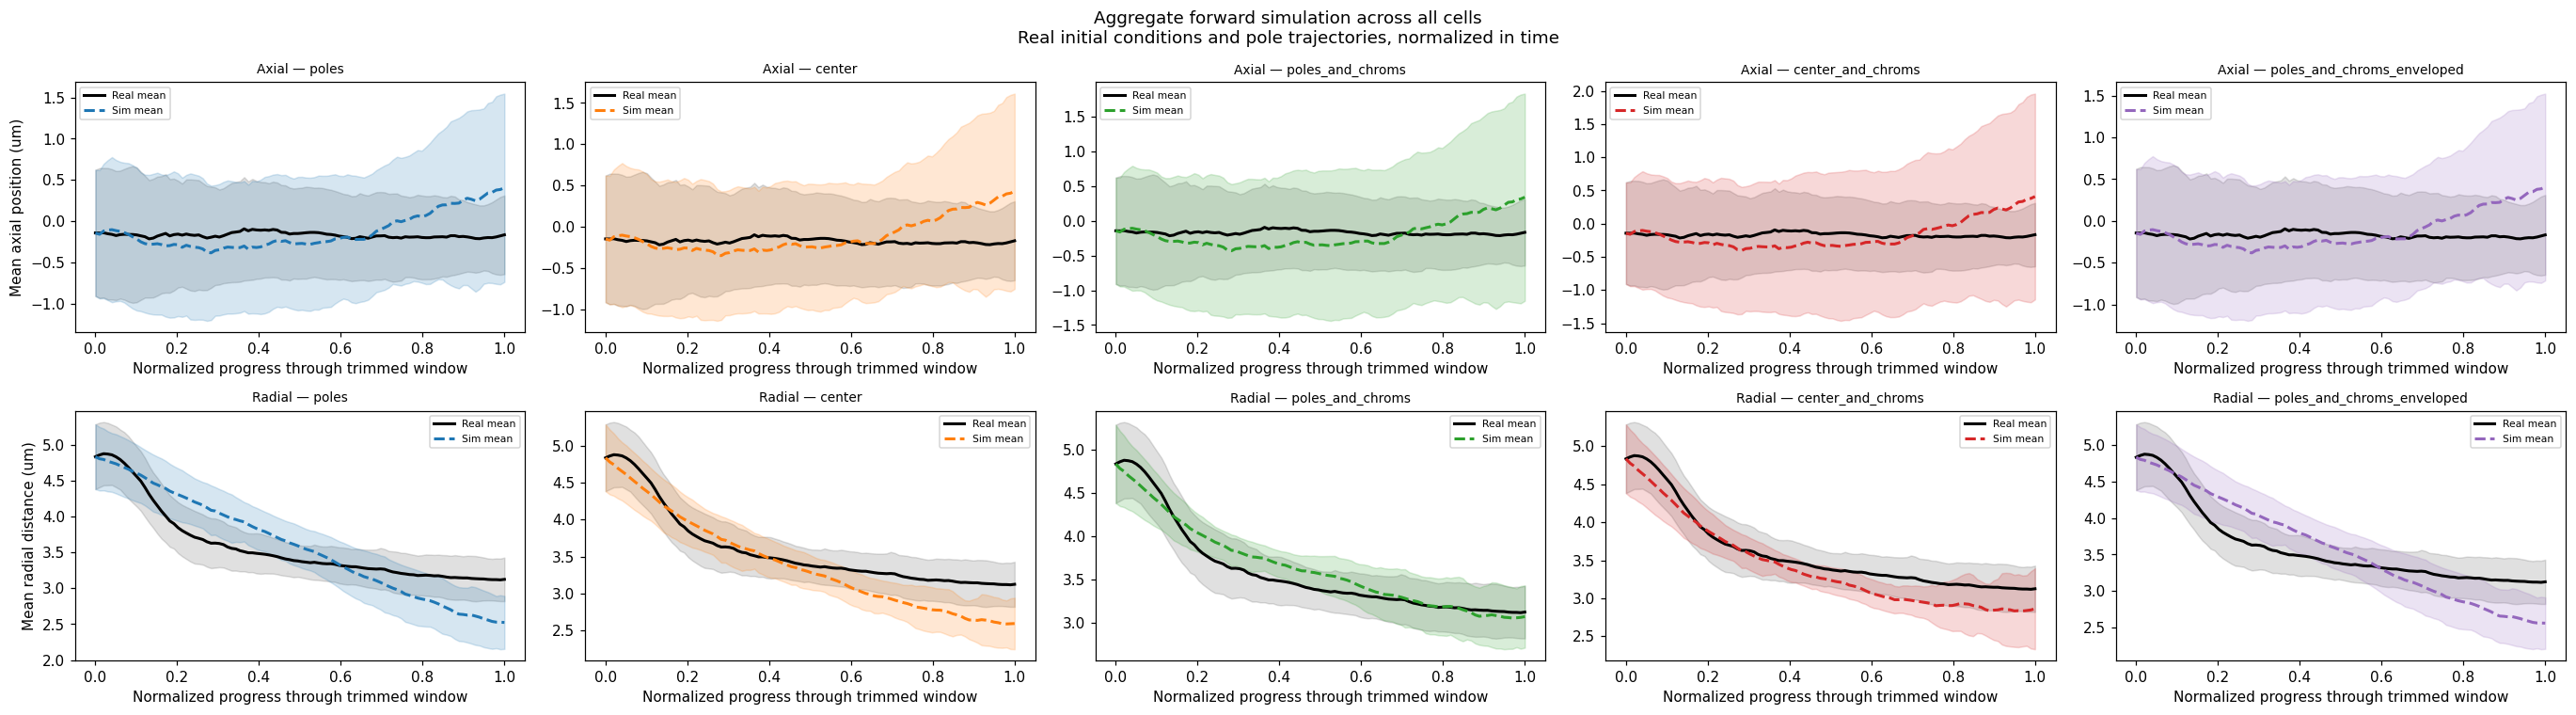

In [15]:
AGG_NORM_GRID = 100
print("Aggregating full-data forward simulations across all cells...")

agg_real_axial = []
agg_real_radial = []
agg_sim_axial: dict[str, list[np.ndarray]] = {t: [] for t in TOPOLOGIES}
agg_sim_radial: dict[str, list[np.ndarray]] = {t: [] for t in TOPOLOGIES}

for cell_idx, cell in enumerate(cells):
    sf_cell_real = spindle_frame(cell)
    agg_real_axial.append(_interp_to_unit_grid(np.nanmean(sf_cell_real.axial, axis=1), n_grid=AGG_NORM_GRID))
    agg_real_radial.append(_interp_to_unit_grid(np.nanmean(sf_cell_real.radial, axis=1), n_grid=AGG_NORM_GRID))

    for topo_index, topology in enumerate(TOPOLOGIES):
        _traj, sf_sim = _simulate_cell_once(cell, models[topology])
        agg_sim_axial[topology].append(
            _interp_to_unit_grid(np.nanmean(sf_sim.axial, axis=1), n_grid=AGG_NORM_GRID)
        )
        agg_sim_radial[topology].append(
            _interp_to_unit_grid(np.nanmean(sf_sim.radial, axis=1), n_grid=AGG_NORM_GRID)
        )

agg_real_axial = np.stack(agg_real_axial, axis=0)
agg_real_radial = np.stack(agg_real_radial, axis=0)
norm_time = np.linspace(0.0, 1.0, AGG_NORM_GRID)

fig, axes = plt.subplots(2, len(TOPOLOGIES), figsize=(5 * len(TOPOLOGIES), 7), squeeze=False)
for col, topology in enumerate(TOPOLOGIES):
    ax_axial = axes[0, col]
    ax_radial = axes[1, col]

    sim_axial_stack = np.stack(agg_sim_axial[topology], axis=0)
    sim_radial_stack = np.stack(agg_sim_radial[topology], axis=0)

    real_axial_mean = np.nanmean(agg_real_axial, axis=0)
    real_axial_std = np.nanstd(agg_real_axial, axis=0)
    real_radial_mean = np.nanmean(agg_real_radial, axis=0)
    real_radial_std = np.nanstd(agg_real_radial, axis=0)

    sim_axial_mean = np.nanmean(sim_axial_stack, axis=0)
    sim_axial_std = np.nanstd(sim_axial_stack, axis=0)
    sim_radial_mean = np.nanmean(sim_radial_stack, axis=0)
    sim_radial_std = np.nanstd(sim_radial_stack, axis=0)

    color = f"C{col}"
    ax_axial.plot(norm_time, real_axial_mean, "k-", linewidth=2.0, label="Real mean")
    ax_axial.fill_between(
        norm_time,
        real_axial_mean - real_axial_std,
        real_axial_mean + real_axial_std,
        color="k",
        alpha=0.12,
    )
    ax_axial.plot(norm_time, sim_axial_mean, color=color, linestyle="--", linewidth=2.0, label="Sim mean")
    ax_axial.fill_between(
        norm_time,
        sim_axial_mean - sim_axial_std,
        sim_axial_mean + sim_axial_std,
        color=color,
        alpha=0.18,
    )

    ax_radial.plot(norm_time, real_radial_mean, "k-", linewidth=2.0, label="Real mean")
    ax_radial.fill_between(
        norm_time,
        real_radial_mean - real_radial_std,
        real_radial_mean + real_radial_std,
        color="k",
        alpha=0.12,
    )
    ax_radial.plot(norm_time, sim_radial_mean, color=color, linestyle="--", linewidth=2.0, label="Sim mean")
    ax_radial.fill_between(
        norm_time,
        sim_radial_mean - sim_radial_std,
        sim_radial_mean + sim_radial_std,
        color=color,
        alpha=0.18,
    )

    ax_axial.set_title(f"Axial — {topology}", fontsize=9)
    ax_radial.set_title(f"Radial — {topology}", fontsize=9)
    ax_axial.set_xlabel("Normalized progress through trimmed window")
    ax_radial.set_xlabel("Normalized progress through trimmed window")
    if col == 0:
        ax_axial.set_ylabel("Mean axial position (um)")
        ax_radial.set_ylabel("Mean radial distance (um)")
    ax_axial.legend(fontsize=7)
    ax_radial.legend(fontsize=7)

fig.suptitle("Aggregate forward simulation across all cells\n"
             "Real initial conditions and pole trajectories, normalized in time")
fig.tight_layout()
plt.show()

In [16]:
print("Running leave-one-cell-out deterministic rollout validation "
      f"({len(TOPOLOGIES)} topologies × {len(cells)} folds)...")
rollout_results: dict[str, RolloutCVResult] = {}
for topo_index, topology in enumerate(TOPOLOGIES):
    rollout_results[topology] = rollout_cross_validate(
        cells,
        configs[topology],
        horizons=ROLLOUT_HORIZONS,
        deterministic=True,
    )
    rr = rollout_results[topology]
    h_idx = list(rr.horizons).index(H_PRIMARY)
    primary_mse = float(np.nanmean(rr.horizon_ensemble_mse[:, h_idx]))
    print(f"  {topology:<22}  ens_MSE(h={H_PRIMARY})={primary_mse:.5f}  "
          f"path_MSE={np.nanmean(rr.path_mse):.5f}  "
          f"endpoint_MSE={np.nanmean(rr.endpoint_mean_error):.5f}  "
          f"final_W1(ax,rad)=({np.nanmean(rr.final_axial_wasserstein):.4f}, "
          f"{np.nanmean(rr.final_radial_wasserstein):.4f})")

Running leave-one-cell-out deterministic rollout validation (5 topologies × 12 folds)...


  poles                   ens_MSE(h=10)=1.60084  path_MSE=5.29410  endpoint_MSE=2.16936  final_W1(ax,rad)=(1.0302, 0.7259)


  center                  ens_MSE(h=10)=1.53926  path_MSE=5.84387  endpoint_MSE=1.99553  final_W1(ax,rad)=(1.2009, 0.6327)


  poles_and_chroms        ens_MSE(h=10)=1.54742  path_MSE=5.71413  endpoint_MSE=2.87869  final_W1(ax,rad)=(1.2706, 0.4160)


  center_and_chroms       ens_MSE(h=10)=1.55687  path_MSE=13.42481  endpoint_MSE=2.80236  final_W1(ax,rad)=(1.6576, 0.6470)


  poles_and_chroms_enveloped  ens_MSE(h=10)=1.59367  path_MSE=5.23887  endpoint_MSE=2.07348  final_W1(ax,rad)=(1.0047, 0.6658)


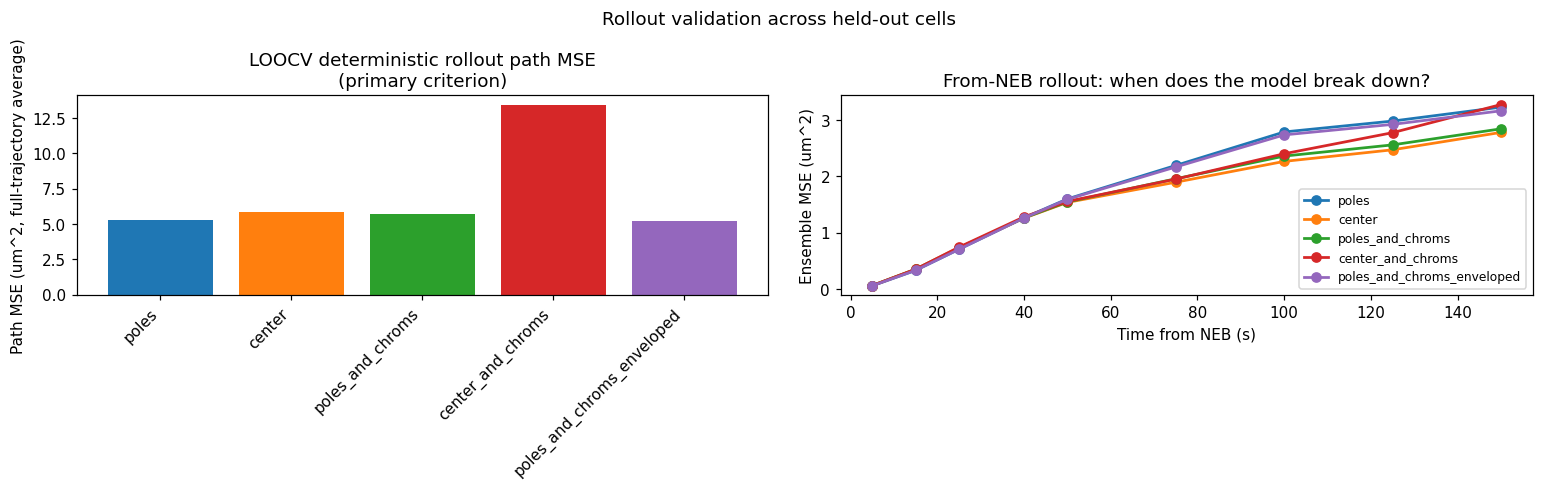


LOOCV rollout summary (sorted by primary criterion: path MSE)
  Topology                      Path MSE   Ens MSE@h=10      1-step CV
---------------------------------------------------------------------------
  poles_and_chroms_enveloped      5.23887        1.59367     0.00077577
  poles                          5.29410        1.60084     0.00077667
  poles_and_chroms               5.71413        1.54742     0.00077118
  center                         5.84387        1.53926     0.00077469
  center_and_chroms             13.42481        1.55687     0.00077261


In [17]:
# Primary model-selection criterion: leave-one-cell-out deterministic
# drift-rollout *path* MSE — average squared (real - sim) chromosome
# position over all frames of the trimmed early-prometaphase trajectory.
# This integrates the horizon-resolved error over the predeclared
# analysis window (NEB to ~0.4 of NEB-AO, ~150 s), avoiding an arbitrary
# single-horizon choice.  The from-NEB ensemble MSE at h=H_PRIMARY and
# the rolling-window forecast curve below are reported as supporting
# diagnostics that the path-MSE conclusion is not hiding a single-horizon
# failure mode.
path_mse_score = {
    topology: float(np.nanmean(rollout_results[topology].path_mse))
    for topology in TOPOLOGIES
}
sorted_topo_rollout = sorted(TOPOLOGIES, key=lambda t: path_mse_score[t])

# Diagnostic ensemble-MSE @ H_PRIMARY (kept for the supporting display)
_primary_h_idx = list(rollout_results[TOPOLOGIES[0]].horizons).index(H_PRIMARY)
rollout_ensemble_mse_score = {
    topology: float(np.nanmean(
        rollout_results[topology].horizon_ensemble_mse[:, _primary_h_idx]
    ))
    for topology in TOPOLOGIES
}

# Display: primary path-MSE bar chart + from-NEB horizon curve diagnostic
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
x = np.arange(len(TOPOLOGIES))

axes[0].bar(x, [path_mse_score[t] for t in TOPOLOGIES],
            color=[f"C{i}" for i in range(len(TOPOLOGIES))])
axes[0].set_xticks(x)
axes[0].set_xticklabels(TOPOLOGIES, rotation=45, ha="right")
axes[0].set_ylabel("Path MSE (um^2, full-trajectory average)")
axes[0].set_title("LOOCV deterministic rollout path MSE\n(primary criterion)")

horizons_neb = rollout_results[TOPOLOGIES[0]].horizons
dt = cells[0].dt
for topo_idx, topology in enumerate(TOPOLOGIES):
    rr = rollout_results[topology]
    axes[1].plot(
        horizons_neb * dt,
        np.nanmean(rr.horizon_ensemble_mse, axis=0),
        marker="o", linewidth=1.8, label=topology,
    )
axes[1].set_xlabel("Time from NEB (s)")
axes[1].set_ylabel("Ensemble MSE (um^2)")
axes[1].set_title("From-NEB rollout: when does the model break down?")
axes[1].legend(fontsize=8)

fig.suptitle("Rollout validation across held-out cells")
fig.tight_layout()
plt.show()

# Summary table sorted by primary criterion (path MSE), with diagnostic
# ensemble MSE @h=H_PRIMARY and 1-step CV alongside.
print(f"\nLOOCV rollout summary (sorted by primary criterion: path MSE)")
print(f"  {'Topology':<25} {'Path MSE':>12} {'Ens MSE@h=' + str(H_PRIMARY):>14} {'1-step CV':>14}")
print("-" * 75)
for topology in sorted_topo_rollout:
    print(f"  {topology:<25} {path_mse_score[topology]:>12.5f} "
          f"{rollout_ensemble_mse_score[topology]:>14.5f} "
          f"{cv_results[topology].mean_error:>14.8f}")

### Rolling-window forecast horizon

The from-NEB rollout above shows when the model breaks down from its
initial conditions.  The rolling-window forecast asks a complementary
question: over what timescales is the model accurate, independent of
position in the trajectory?

For each held-out cell, we re-initialize from real positions at every
valid starting frame, simulate forward h steps, and compare to reality.

In [18]:
from chromlearn.model_fitting.fit import forecast_horizon_cross_validate

FORECAST_HORIZONS = (1, 3, 5, 8, 10, 15, 20, 25, 30)

print("Running rolling-window deterministic forecast validation "
      f"({len(TOPOLOGIES)} topologies x {len(cells)} folds)...")
forecast_results: dict[str, "ForecastHorizonResult"] = {}
for topo_idx, topology in enumerate(TOPOLOGIES):
    forecast_results[topology] = forecast_horizon_cross_validate(
        cells,
        configs[topology],
        horizons=FORECAST_HORIZONS,
        deterministic=True,
    )
    fr = forecast_results[topology]
    print(f"  {topology:<22}  "
          + "  ".join(f"h={h}: {np.nanmean(fr.ensemble_mse[:, hi]):.5f}"
                      for hi, h in enumerate(fr.horizons)))

Running rolling-window deterministic forecast validation (5 topologies x 12 folds)...


  poles                   h=1: 0.05825  h=3: 0.22395  h=5: 0.40303  h=8: 0.67940  h=10: 0.86824  h=15: 1.35098  h=20: 1.86502  h=25: 2.39862  h=30: 2.95589


  center                  h=1: 0.05811  h=3: 0.22179  h=5: 0.39601  h=8: 0.66025  h=10: 0.84085  h=15: 1.31652  h=20: 1.85928  h=25: 2.46298  h=30: 3.12059


  poles_and_chroms        h=1: 0.05784  h=3: 0.21944  h=5: 0.39002  h=8: 0.64669  h=10: 0.81967  h=15: 1.26310  h=20: 1.75387  h=25: 2.28757  h=30: 2.86702


  center_and_chroms       h=1: 0.05795  h=3: 0.22081  h=5: 0.39430  h=8: 0.65863  h=10: 0.84070  h=15: 1.32680  h=20: 1.89515  h=25: 2.53940  h=30: 3.25698


  poles_and_chroms_enveloped  h=1: 0.05819  h=3: 0.22339  h=5: 0.40163  h=8: 0.67622  h=10: 0.86356  h=15: 1.34169  h=20: 1.85059  h=25: 2.37890  h=30: 2.93067


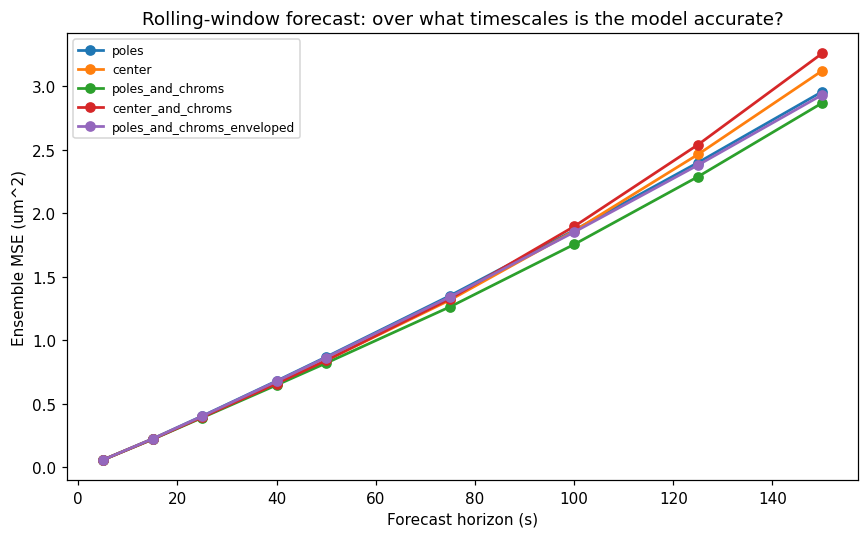

In [19]:
fig_fc, ax_fc = plt.subplots(figsize=(8, 5))
for topo_idx, topology in enumerate(TOPOLOGIES):
    fr = forecast_results[topology]
    ax_fc.plot(
        fr.horizons * dt,
        np.nanmean(fr.ensemble_mse, axis=0),
        marker="o", linewidth=1.8, label=topology,
    )
ax_fc.set_xlabel("Forecast horizon (s)")
ax_fc.set_ylabel("Ensemble MSE (um^2)")
ax_fc.set_title("Rolling-window forecast: over what timescales is the model accurate?")
ax_fc.legend(fontsize=8)
fig_fc.tight_layout()
plt.show()

## Metric concordance

Do the supporting diagnostics agree with the primary path-MSE ranking?

In [20]:
metric_rankings: dict[str, list[str]] = {}
metric_rankings[f"Ens MSE @h={H_PRIMARY}"] = sorted(TOPOLOGIES, key=lambda t: rollout_ensemble_mse_score[t])
metric_rankings["1-step CV"] = sorted(TOPOLOGIES, key=lambda t: cv_results[t].mean_error)

# Add forecast-horizon ranking at the longest horizon
longest_hi = -1
forecast_at_longest = {
    t: float(np.nanmean(forecast_results[t].ensemble_mse[:, longest_hi]))
    for t in TOPOLOGIES
}
metric_rankings["Forecast (long h)"] = sorted(TOPOLOGIES, key=lambda t: forecast_at_longest[t])

print("Metric concordance -- topology ranking")
print("=" * 80)
header = f"{'Metric':<18}" + "".join(f"  {'#' + str(i+1):<18}" for i in range(len(TOPOLOGIES)))
print(header)
print("-" * 80)
for metric_name, ranking in metric_rankings.items():
    row = f"  {metric_name:<18}" + "".join(f"  {t:<18}" for t in ranking)
    print(row)
print("=" * 80)

rank1_topologies = {r[0] for r in metric_rankings.values()}
if len(rank1_topologies) == 1:
    print(f"All metrics agree: {rank1_topologies.pop()} is best.")
else:
    print(f"Rank-1 picks: {', '.join(f'{m}: {r[0]}' for m, r in metric_rankings.items())}")

Metric concordance -- topology ranking
Metric              #1                  #2                  #3                  #4                  #5                
--------------------------------------------------------------------------------
  Ens MSE @h=10       center              poles_and_chroms    center_and_chroms   poles_and_chroms_enveloped  poles             
  1-step CV           poles_and_chroms    center_and_chroms   center              poles_and_chroms_enveloped  poles             
  Forecast (long h)   poles_and_chroms    poles_and_chroms_enveloped  poles               center              center_and_chroms 
Rank-1 picks: Ens MSE @h=10: center, 1-step CV: poles_and_chroms, Forecast (long h): poles_and_chroms


## Model selection summary

**Primary criterion**: leave-one-cell-out deterministic drift-rollout
**path MSE** — mean squared (real - sim) chromosome position over all
frames of the trimmed early-prometaphase trajectory (NEB to ``frac=0.4``
of NEB-AO, ~150 s).  This integrates the horizon-resolved error over
the predeclared analysis window, avoiding an arbitrary single-horizon
choice.  The from-NEB ensemble MSE at ``h=H_PRIMARY`` (Alex's
diagnostic horizon), the rolling-window forecast curve, the final-frame
Wasserstein distance, and the endpoint MSE are reported as supporting
diagnostics — they show whether the path-MSE conclusion is hiding a
single-horizon failure mode.

**Biological admissibility**: ``poles_and_chroms`` and
``center_and_chroms`` allow free-form (full-range) chromosome-chromosome
forces, which have no known biological basis for mammalian mitosis.
We treat these as flexible nuisance-absorbing upper bounds: they may
capture missing physics (e.g. common spindle transport) without being
physically interpretable.  The biologically admissible candidate set
is ``poles``, ``center``, and ``poles_and_chroms_enveloped`` (which
adds steric chromosome-chromosome repulsion at the chromatid contact
scale ~1-2 um).

**Selection**: ``poles_and_chroms_enveloped`` gives the lowest path
MSE among biologically admissible models.  We adopt it as the
canonical model.  ``center`` is reported but not preferred: it is a
phenomenological attractor toward the spindle midpoint, not derivable
from the kinetochore-microtubule force balance that motivates the
``poles`` topology family.

Primary criterion: leave-one-cell-out drift-rollout path MSE
  Topology                      Path MSE   vs best   Ens MSE@h=10   admissible
--------------------------------------------------------------------------------
  poles_and_chroms_enveloped      5.23887     +0.0%        1.59367          yes
  poles                          5.29410     +1.1%        1.60084          yes
  poles_and_chroms               5.71413     +9.1%        1.54742  nuisance UB
  center                         5.84387    +11.5%        1.53926          yes
  center_and_chroms             13.42481   +156.3%        1.55687  nuisance UB

Paired foldwise differences in path MSE (reference: poles_and_chroms_enveloped, best biologically admissible)
  Topology                     mean diff     SE(diff)    diff/SE
  poles                      +5.5233e-02   2.3306e-02       2.37
  center                     +6.0500e-01   1.9121e-01       3.16
  poles_and_chroms_enveloped  +0.0000e+00   0.0000e+00       0.00

Selected t

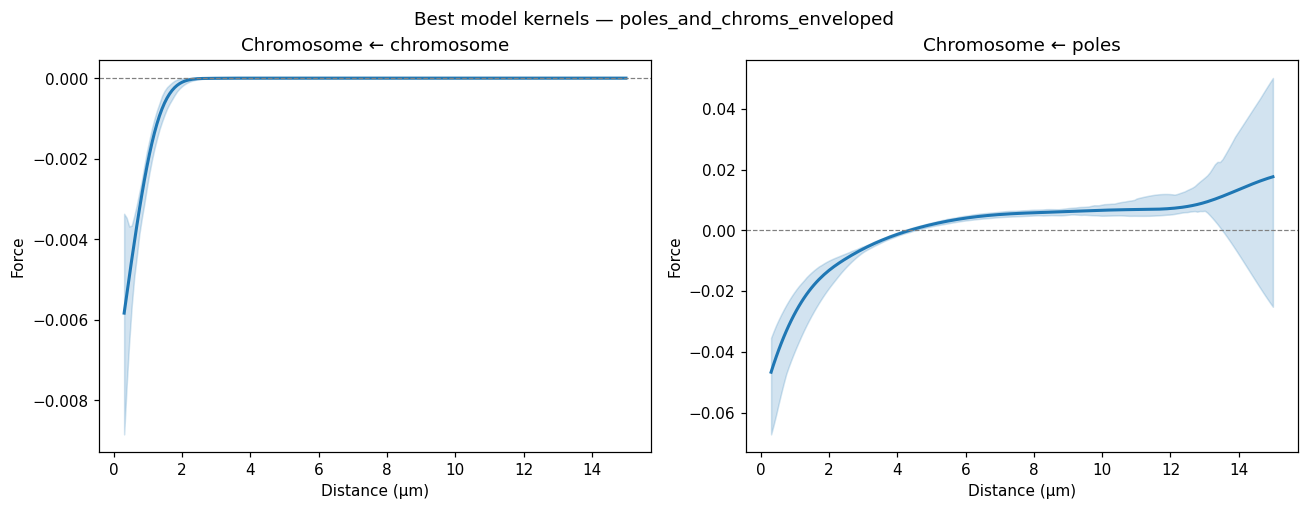

In [21]:
# Biologically admissible candidate set: models without a free-form
# (full-range) chromosome-chromosome kernel.  poles_and_chroms and
# center_and_chroms permit long-range xx forces with no known
# biological basis; treated as flexible nuisance-absorbing upper bounds.
ADMISSIBLE_TOPOLOGIES = ["poles", "center", "poles_and_chroms_enveloped"]
sorted_admissible = sorted(ADMISSIBLE_TOPOLOGIES, key=lambda t: path_mse_score[t])
best_admissible = sorted_admissible[0]

print(f"Primary criterion: leave-one-cell-out drift-rollout path MSE")
print("=" * 80)
best_path_score = path_mse_score[best_admissible]
print(f"  {'Topology':<25} {'Path MSE':>12} {'vs best':>9} "
      f"{'Ens MSE@h=' + str(H_PRIMARY):>14} {'admissible':>12}")
print("-" * 80)
for t in sorted_topo_rollout:
    rel_pct = 100.0 * (path_mse_score[t] - best_path_score) / best_path_score if best_path_score > 0 else np.nan
    admissible_marker = "yes" if t in ADMISSIBLE_TOPOLOGIES else "nuisance UB"
    print(f"  {t:<25} {path_mse_score[t]:>12.5f} {rel_pct:>+8.1f}% "
          f"{rollout_ensemble_mse_score[t]:>14.5f} {admissible_marker:>12}")

# Paired foldwise differences on path MSE among biologically admissible models
ref_path = rollout_results[best_admissible].path_mse
print(f"\nPaired foldwise differences in path MSE "
      f"(reference: {best_admissible}, best biologically admissible)")
print(f"  {'Topology':<25} {'mean diff':>12} {'SE(diff)':>12} {'diff/SE':>10}")
for topology in ADMISSIBLE_TOPOLOGIES:
    rr = rollout_results[topology]
    diff = rr.path_mse - ref_path
    valid = np.isfinite(diff)
    n = int(valid.sum())
    mean_diff = float(np.mean(diff[valid])) if n > 0 else np.inf
    se_diff = float(np.std(diff[valid], ddof=1) / np.sqrt(n)) if n > 1 else np.inf
    ratio = mean_diff / se_diff if se_diff > 0 and se_diff < np.inf else 0.0
    print(f"  {topology:<25} {mean_diff:>+12.4e} {se_diff:>12.4e} {ratio:>10.2f}")
print("=" * 80)

# Selection: by primary criterion (path MSE) among biologically admissible models.
best_topology = best_admissible
print(f"\nSelected topology: {best_topology}")
print("  Justification: lowest LOOCV path-averaged held-out trajectory error")
print("  among biologically admissible models (poles, center, poles_and_chroms_enveloped).")
print("  Free-form xx variants (poles_and_chroms, center_and_chroms) are reported")
print("  as nuisance-absorbing upper bounds; not physically interpretable.")
print("  Center is reported but is phenomenological (chrom-midpoint attraction is")
print("  not derivable from the kinetochore-microtubule force balance underlying poles).")

# Final kernel plot for the winner
print(f"\nFinal kernel plot for best model ({best_topology}):")
fig = plot_kernels(models[best_topology], bootstrap=boot_results[best_topology])
fig.suptitle(f"Best model kernels — {best_topology}", y=1.02)
plt.show()

## Scope of comparison

The topologies above form a restricted, physically motivated candidate
family (pairwise SFI-inspired kernels with pole-geometry and optional
chromosome-chromosome terms).  The selection identifies the best model
*within this family*; it does not exhaust all plausible interaction
structures.  Extensions worth testing in future work include an explicit
common-transport / advection term and a `poles + center` hybrid topology.

## Note on diffusion

Spatially-varying diffusion D(x) analysis has been moved to
**Notebook 06 (06_diffusion_landscape.py)**, which provides a thorough
investigation with multiple estimators, per-cell consistency checks, and
comparison across coordinate axes.